# Spot-On Analysis Notebook
### Jump Length Distribution Fitting for Single-Particle Tracking

Uses the [`fastspt`](https://gitlab.com/tjian-darzacq-lab/fastspt) package (the Python backend of
[Spot-On](https://spoton.berkeley.edu)) for the core model and fitting, wrapped in a clean
notebook with interactive controls, publication figures, and batch comparison.

**What this notebook does:**
1. Auto-patches `fastspt` for Python 3 / NumPy 2 compatibility
2. Loads trajectory data from **TrackMate XML**, **CSV**, or **XLSX**
3. Splits trajectories at large frame gaps (prevents IndexError)
4. Computes **jump length distributions** using `fastspt`
5. Fits a **2-state or 3-state kinetic model** with defocalization correction
6. Provides **interactive sliders** (like the Spot-On GUI fitting tab)
7. Produces **Spot-On style histograms** and publication-quality figures

**Install:**
```
conda create -n spoton python=3.9
conda activate spoton
pip install fastspt lmfit xmltodict numpy scipy matplotlib pandas openpyxl ipywidgets
```

---
*Cite: Hansen AS et al. (2018) Spot-On: robust model-based analysis of*
*single-particle tracking experiments. eLife 7:e33125*

## Cell 1 — Patch `fastspt` for Python 3 / NumPy ≥ 2

Run this cell **once** after installing fastspt. It fixes:
- Python 2 absolute imports → relative imports
- Deprecated `np.float_()` → `np.float64()`

Safe to re-run — it checks before patching.

In [1]:
import importlib, importlib.util, os, re, sys

# ── Locate fastspt package WITHOUT importing it ──
# (We can't import it yet — the broken imports are why we need this patcher!)
spec = importlib.util.find_spec('fastspt')
if spec is None or spec.origin is None:
    raise ModuleNotFoundError(
        'fastspt not found. Install with: pip install fastspt')
FASTSPT_DIR = os.path.dirname(spec.origin)
print(f'Found fastspt at: {FASTSPT_DIR}')

# ── Define patches ──
PATCHES = {
    '__init__.py': {
        'replace_entire': True,
        'content': (
            'from fastspt.fastspt import *\n'
            'from .version import __version__\n'
            '\n'
            'from . import fastSPT_tools, readers, writers\n'
            'try:\n'
            '    from . import fastSPT_plot\n'
            'except Exception as e:\n'
            '    print("Could not import the plot submodule, error:")\n'
            '    print(e)\n'
        ),
    },
    'readers.py': {
        'replace_entire': False,
        'fixes': [
            ('import format4DN', 'from . import format4DN'),
            # NumPy 2.4: fix deprecated dtype() call
            ("DT = np.dtype('<f8', '<f8', 'uint16')",
             "DT = np.dtype([('f1', '<f8'), ('f2', '<f8'), ('f3', 'uint16')])"),
        ],
    },
    'format4DN.py': {
        'replace_entire': False,
        'fixes': [
            ('import readers', 'from . import readers'),
        ],
    },
    'fastspt.py': {
        'replace_entire': False,
        'fixes': [
            ('np.float_(', 'np.float64('),
        ],
    },
}

# ── Apply patches ──
patched_any = False
for fname, spec_dict in PATCHES.items():
    fpath = os.path.join(FASTSPT_DIR, fname)
    if not os.path.exists(fpath):
        print(f'  SKIP  {fname} (not found)')
        continue

    with open(fpath, 'r', encoding='utf-8') as f:
        original = f.read()

    if spec_dict.get('replace_entire'):
        expected = spec_dict['content']
        if original.strip() == expected.strip():
            print(f'  OK    {fname} (already patched)')
            continue
        new_content = expected
    else:
        new_content = original
        needs_patch = False
        for old, new in spec_dict['fixes']:
            if old in new_content and new not in new_content:
                new_content = new_content.replace(old, new)
                needs_patch = True
        if not needs_patch:
            print(f'  OK    {fname} (already patched)')
            continue

    with open(fpath, 'w', encoding='utf-8') as f:
        f.write(new_content)
    print(f'  FIXED {fname}')
    patched_any = True

if patched_any:
    print('\n>>> Patches applied. Clearing module cache...')
    to_remove = [k for k in sys.modules if k.startswith('fastspt')]
    for k in to_remove:
        del sys.modules[k]
    print('>>> Done. Proceed to the next cell.')
else:
    print('\nAll files already patched — no changes needed ✓')


Found fastspt at: C:\Users\MQ10002204\AppData\Local\anaconda3\envs\SMT\lib\site-packages\fastspt
  OK    __init__.py (already patched)
  OK    readers.py (already patched)
  OK    format4DN.py (already patched)
  OK    fastspt.py (already patched)

All files already patched — no changes needed ✓


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings, os, glob, time
from pathlib import Path
import xml.etree.ElementTree as ET

# fastspt — the core library
import fastspt
from fastspt.fastspt import (compute_jump_length_distribution,
                              fit_jump_length_distribution,
                              simulate_jump_length_distribution,
                              generate_jump_length_distribution)
from fastspt.readers import to_fastSPT

# lmfit — used internally by fastspt
import lmfit

# Optional: interactive widgets
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print('ipywidgets not installed — interactive controls disabled.')
    print('Install with: pip install ipywidgets')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.facecolor': 'white',
})

print(f'fastspt loaded ✓  (from {fastspt.__file__})')
print(f'numpy {np.__version__}, lmfit {lmfit.__version__}')

fastspt loaded ✓  (from C:\Users\MQ10002204\AppData\Local\anaconda3\envs\SMT\lib\site-packages\fastspt\__init__.py)
numpy 2.0.2, lmfit 1.3.4


## 2. Configuration

Adjust parameters using the controls below. These mirror the Spot-On GUI settings panels.
Click **Apply Configuration** when done.


In [3]:
# ═══════════════════════════════════════════════════════════
# CONFIGURATION GUI
# ═══════════════════════════════════════════════════════════
CONFIG = {}  # populated by the GUI or manually

if HAS_WIDGETS:
    from IPython.display import display, HTML

    style  = {'description_width': '140px'}
    narrow = widgets.Layout(width='420px')

    # ══════════════ Acquisition ══════════════
    w_dt = widgets.FloatText(
        value=0.03449, description='Frame interval (s):',
        style=style, layout=narrow, step=0.001)
    w_px = widgets.FloatText(
        value=0.1285, description='Pixel size (µm/px):',
        style=style, layout=narrow, step=0.001)
    w_um = widgets.Checkbox(
        value=True, description='Positions already in µm',
        style=style, layout=narrow)

    # ══════════════ Histogram ══════════════
    w_timepoints = widgets.IntSlider(
        value=6, min=3, max=20, step=1,
        description='TimePoints:', style=style, layout=narrow)
    w_jumps = widgets.IntSlider(
        value=4, min=1, max=10, step=1,
        description='Jumps to consider:', style=style, layout=narrow)
    w_gaps = widgets.IntSlider(
        value=1, min=0, max=3, step=1,
        description='Gaps allowed:', style=style, layout=narrow)
    w_entire = widgets.Checkbox(
        value=False, description='Use entire trajectory',
        style=style, layout=narrow)
    w_binw = widgets.FloatText(
        value=0.010, description='Bin width (µm):',
        style=style, layout=narrow, step=0.005)
    w_maxjump = widgets.FloatText(
        value=3, description='Max jump (µm):',
        style=style, layout=narrow, step=0.25)

    # ══════════════ Model ══════════════
    w_states = widgets.ToggleButtons(
        options=[2, 3], value=2,
        description='States:', style=style,
        button_style='', tooltips=['Bound + Free', 'Bound + Slow + Fast'])
    w_fitto = widgets.ToggleButtons(
        options=['PDF', 'CDF'], value='CDF',
        description='Fit to:', style=style, button_style='')
    w_fitsig = widgets.Checkbox(
        value=True, description='Fit localization error',
        style=style, layout=narrow)
    w_locerr = widgets.FloatText(
        value=0.035, description='σ_loc (µm):',
        style=style, layout=narrow, step=0.005)
    w_iters = widgets.IntSlider(
        value=3, min=1, max=20, step=1,
        description='Iterations:', style=style, layout=narrow)

    # ══════════════ Z-correction ══════════════
    w_zcorr = widgets.Checkbox(
        value=True, description='Defocalization correction',
        style=style, layout=narrow)
    w_dz = widgets.FloatSlider(
        value=0.7, min=0.1, max=2.0, step=0.05,
        description='Δz (µm):', style=style, layout=narrow,
        readout_format='.2f')
    w_acorr = widgets.FloatText(
        value=0.15109, description='a coefficient:',
        style=style, layout=narrow, step=0.001)
    w_bcorr = widgets.FloatText(
        value=0.20377, description='b coefficient:',
        style=style, layout=narrow, step=0.001)

    # ══════════════ Bounds (dynamic) ══════════════
    _bounds = {'lb': [], 'ub': []}   # mutable container
    bounds_box = widgets.VBox()

    def get_default_bounds(n_states, fit_sigma):
        if n_states == 2:
            labels = ['D_free', 'D_bound', 'F_bound']
            lb = [0.15, 0.0005, 0.0]
            ub = [3, 0.08,   1.0]
        else:
            labels = ['D_fast', 'D_med', 'D_bound', 'F_fast', 'F_bound']
            lb = [0.5, 0.15, 0.0005, 0.0, 0.0]
            ub = [25.0, 5.0, 0.08,   1.0, 1.0]
        if fit_sigma:
            labels.append('σ_loc')
            lb.append(0.01)
            ub.append(0.10)
        return labels, lb, ub

    def rebuild_bounds(*args):
        labels, lb_def, ub_def = get_default_bounds(w_states.value, w_fitsig.value)
        _bounds['lb'] = []
        _bounds['ub'] = []
        rows = []
        for i, lbl in enumerate(labels):
            w_lb = widgets.FloatText(value=lb_def[i],
                layout=widgets.Layout(width='100px'), step=0.01)
            w_ub = widgets.FloatText(value=ub_def[i],
                layout=widgets.Layout(width='100px'), step=0.01)
            _bounds['lb'].append(w_lb)
            _bounds['ub'].append(w_ub)
            rows.append(widgets.HBox([
                widgets.Label(f'{lbl}:', layout=widgets.Layout(width='80px')),
                widgets.Label('min', layout=widgets.Layout(width='30px')),
                w_lb,
                widgets.Label('max', layout=widgets.Layout(width='35px')),
                w_ub,
            ]))
        bounds_box.children = rows

    w_states.observe(rebuild_bounds, 'value')
    w_fitsig.observe(rebuild_bounds, 'value')
    rebuild_bounds()

    # ══════════════ Apply button ══════════════
    apply_btn = widgets.Button(
        description='  Apply Configuration',
        button_style='success', icon='check',
        layout=widgets.Layout(width='250px', height='36px'))
    status = widgets.Output()

    def on_apply(btn):
        CONFIG.update({
            'FRAME_INTERVAL':    w_dt.value,
            'PIXEL_SIZE':        w_px.value,
            'DATA_IN_UM':        w_um.value,
            'TIME_POINTS':       w_timepoints.value,
            'JUMPS_TO_CONSIDER': w_jumps.value,
            'GAPS_ALLOWED':      w_gaps.value,
            'USE_ENTIRE_TRAJ':   w_entire.value,
            'BIN_WIDTH':         w_binw.value,
            'MAX_JUMP':          w_maxjump.value,
            'NUM_STATES':        w_states.value,
            'FIT_TO':            w_fitto.value,
            'FIT_SIGMA':         w_fitsig.value,
            'LOC_ERROR':         w_locerr.value,
            'ITERATIONS':        w_iters.value,
            'USE_Z_CORR':        w_zcorr.value,
            'DZ':                w_dz.value,
            'A_CORR':            w_acorr.value,
            'B_CORR':            w_bcorr.value,
            'LB':                [w.value for w in _bounds['lb']],
            'UB':                [w.value for w in _bounds['ub']],
        })
        with status:
            from IPython.display import clear_output
            clear_output()
            print('Configuration applied ✓')
            print(f'  Frame interval : {CONFIG["FRAME_INTERVAL"]*1000:.2f} ms')
            print(f'  Model          : {CONFIG["NUM_STATES"]}-state, fit to {CONFIG["FIT_TO"]}')
            zstr = f'ON (Δz={CONFIG["DZ"]} µm)' if CONFIG['USE_Z_CORR'] else 'OFF'
            print(f'  Z-correction   : {zstr}')
            sstr = 'fitted' if CONFIG['FIT_SIGMA'] else f'fixed at {CONFIG["LOC_ERROR"]*1000:.0f} nm'
            print(f'  Loc. error     : {sstr}')
            print(f'  Bounds (LB)    : {CONFIG["LB"]}')
            print(f'  Bounds (UB)    : {CONFIG["UB"]}')

    apply_btn.on_click(on_apply)

    def toggle_sigma(*args):
        w_locerr.disabled = w_fitsig.value
    w_fitsig.observe(toggle_sigma, 'value')

    # ── Layout ──
    section = lambda t: widgets.HTML(
        f'<h4 style="margin:12px 0 4px 0;color:#2c3e50;'
        f'border-bottom:1px solid #ddd;padding-bottom:4px">{t}</h4>')

    gui = widgets.VBox([
        widgets.HTML('<h3 style="color:#2c3e50">Spot-On Configuration</h3>'),
        section('Acquisition'),
        w_dt, w_px, w_um,
        section('Jump Length Histogram'),
        w_timepoints, w_jumps, w_gaps, w_entire, w_binw, w_maxjump,
        section('Model Fitting'),
        w_states, w_fitto, w_fitsig, w_locerr, w_iters,
        section('Defocalization Correction'),
        w_zcorr, w_dz, w_acorr, w_bcorr,
        section('Parameter Bounds'),
        bounds_box,
        widgets.HTML('<div style="height:8px"></div>'),
        apply_btn,
        status,
    ], layout=widgets.Layout(padding='10px', border='1px solid #ddd',
                              border_radius='8px', max_width='500px'))

    display(gui)

else:
    CONFIG = {
        'FRAME_INTERVAL': 0.03449, 'PIXEL_SIZE': 0.1285, 'DATA_IN_UM': True,
        'TIME_POINTS': 8, 'JUMPS_TO_CONSIDER': 4, 'GAPS_ALLOWED': 1,
        'USE_ENTIRE_TRAJ': False, 'BIN_WIDTH': 0.010, 'MAX_JUMP': 1.25,
        'NUM_STATES': 2, 'FIT_TO': 'PDF', 'FIT_SIGMA': False,
        'LOC_ERROR': 0.035, 'ITERATIONS': 3, 'USE_Z_CORR': True,
        'DZ': 0.700, 'A_CORR': 0.15109, 'B_CORR': 0.20377,
        'LB': [0.15, 0.0005, 0.0], 'UB': [25.0, 0.08, 1.0],
    }
    print('No widgets — edit CONFIG dict directly:')
    for k, v in CONFIG.items():
        print(f'  CONFIG["{k}"] = {v}')


In [4]:
# ── Unpack CONFIG for downstream cells ──
# (Auto-click Apply if you haven't already)
if not CONFIG:
    if HAS_WIDGETS:
        print('⚠ Click "Apply Configuration" above first, then re-run this cell.')
    else:
        raise RuntimeError('CONFIG is empty — run the configuration cell above.')
else:
    FRAME_INTERVAL    = CONFIG['FRAME_INTERVAL']
    PIXEL_SIZE        = CONFIG['PIXEL_SIZE']
    DATA_IN_UM        = CONFIG['DATA_IN_UM']
    TIME_POINTS       = CONFIG['TIME_POINTS']
    JUMPS_TO_CONSIDER = CONFIG['JUMPS_TO_CONSIDER']
    GAPS_ALLOWED      = CONFIG['GAPS_ALLOWED']
    USE_ENTIRE_TRAJ   = CONFIG['USE_ENTIRE_TRAJ']
    BIN_WIDTH         = CONFIG['BIN_WIDTH']
    MAX_JUMP          = CONFIG['MAX_JUMP']
    NUM_STATES        = CONFIG['NUM_STATES']
    FIT_TO            = CONFIG['FIT_TO']
    FIT_SIGMA         = CONFIG['FIT_SIGMA']
    LOC_ERROR         = CONFIG['LOC_ERROR']
    ITERATIONS        = CONFIG['ITERATIONS']
    USE_Z_CORR        = CONFIG['USE_Z_CORR']
    DZ                = CONFIG['DZ']
    A_CORR            = CONFIG['A_CORR']
    B_CORR            = CONFIG['B_CORR']
    LB                = CONFIG['LB']
    UB                = CONFIG['UB']
    
    print('Config unpacked ✓')
    print(f'  {FRAME_INTERVAL*1000:.2f} ms  |  {NUM_STATES}-state {FIT_TO}  |  '
          f'σ={"fit" if FIT_SIGMA else f"{LOC_ERROR*1000:.0f}nm"}  |  '
          f'Δz={DZ if USE_Z_CORR else "off"}')


Config unpacked ✓
  34.49 ms  |  2-state CDF  |  σ=fit  |  Δz=0.7


## 3. Helper Functions

**Always run this cell** — defines the data loaders and analysis functions
used by both single-file and batch workflows.


In [5]:
import contextlib, io

@contextlib.contextmanager
def _quiet():
    """Suppress stdout (for silencing fastspt's built-in prints during batch)."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield


# ════════════════════════════════════════════════════════════════
# Gap-splitting — prevents IndexError from TrackMate gap-closing
# ════════════════════════════════════════════════════════════════

def split_tracks_at_gaps(traces, max_gap=None, gaps_allowed=1):
    """Split trajectories at frame gaps exceeding allowed size.
    
    TrackMate's gap-closing linker can connect detections across many
    frames. fastspt indexes into an array sized by
    (TimePoints + GapsAllowed*(TimePoints-1)), so frame jumps larger
    than this cause an IndexError.
    
    This splits any track where consecutive frames differ by more than
    (gaps_allowed + 1).
    """
    if max_gap is None:
        max_gap = gaps_allowed + 1
    
    split_traces = []
    n_split = 0
    
    for trace in traces:
        if len(trace) < 2:
            continue
        current_segment = [trace[0]]
        for i in range(1, len(trace)):
            frame_diff = trace[i][3] - trace[i-1][3]
            if frame_diff > max_gap:
                if len(current_segment) >= 2:
                    split_traces.append(current_segment)
                current_segment = [trace[i]]
                n_split += 1
            else:
                current_segment.append(trace[i])
        if len(current_segment) >= 2:
            split_traces.append(current_segment)
    
    if n_split > 0 and os.environ.get('SPOTON_QUIET') != '1':
        print(f'  Gap-splitting: {n_split} tracks split at gaps > {max_gap} frames')
        print(f'  Tracks before: {len(traces)}, after: {len(split_traces)}')
    
    return split_traces


# ════════════════════════════════════════════════════════════════
# Data loaders (CSV, XLSX, XML) — with gap-splitting
# ════════════════════════════════════════════════════════════════

def _read_tabular_file(filepath):
    """Read CSV, TSV, or Excel files into a DataFrame."""
    ext = Path(filepath).suffix.lower()
    if ext in ('.xlsx', '.xls'):
        return pd.read_excel(filepath)
    elif ext == '.tsv':
        return pd.read_csv(filepath, sep='\t')
    else:
        return pd.read_csv(filepath)


def load_trackmate_xml_to_traces(filepath, frame_interval, pixel_size=None,
                                  data_in_um=True, gaps_allowed=1):
    """Parse a full TrackMate XML save file into fastspt trace format.
    
    Returns list of traces: [(x, y, t, frame), ...] per track.
    Positions in µm, times in seconds.
    Splits tracks at large frame gaps to prevent fastspt IndexError.
    """
    tree = ET.parse(filepath)
    root = tree.getroot()
    
    settings = root.find('.//Settings/ImageData')
    if settings is not None:
        xml_dt = float(settings.get('timeinterval', 0))
        xml_px = float(settings.get('pixelwidth', 0))
        if xml_dt > 0:
            print(f'  XML reports frame interval = {xml_dt*1000:.3f} ms')
        if xml_px > 0:
            print(f'  XML reports pixel size     = {xml_px} µm/px')
    
    model = root.find('.//Model')
    if model is None:
        raise ValueError('No <Model> element — is this a TrackMate XML?')
    
    spots_dict = {}
    all_spots = model.find('AllSpots')
    if all_spots is None:
        raise ValueError('No <AllSpots> found in XML.')
    
    for frame_elem in all_spots.findall('SpotsInFrame'):
        for spot in frame_elem.findall('Spot'):
            sid = int(spot.get('ID'))
            x = float(spot.get('POSITION_X'))
            y = float(spot.get('POSITION_Y'))
            frame = int(spot.get('FRAME'))
            if not data_in_um and pixel_size:
                x *= pixel_size
                y *= pixel_size
            spots_dict[sid] = {'x': x, 'y': y, 'frame': frame}
    
    all_tracks = model.find('AllTracks')
    if all_tracks is None:
        raise ValueError('No <AllTracks> found in XML.')
    
    traces = []
    for track in all_tracks.findall('Track'):
        spot_ids = set()
        for edge in track.findall('Edge'):
            spot_ids.add(int(edge.get('SPOT_SOURCE_ID')))
            spot_ids.add(int(edge.get('SPOT_TARGET_ID')))
        
        track_spots = sorted(
            [(spots_dict[s]['x'], spots_dict[s]['y'],
              spots_dict[s]['frame'] * frame_interval,
              spots_dict[s]['frame'])
             for s in spot_ids if s in spots_dict],
            key=lambda p: p[3]
        )
        if len(track_spots) >= 2:
            traces.append(track_spots)
    
    traces = split_tracks_at_gaps(traces, gaps_allowed=gaps_allowed)
    return traces


def load_csv_to_traces(filepath, frame_interval, pixel_size=None,
                        data_in_um=True, gaps_allowed=1):
    """Load CSV/TSV/XLSX into fastspt trace format.
    
    Auto-detects column format:
      - fastspt/Spot-On native:  trajectory, frame, x, y, t
      - TrackMate spots export:  TRACK_ID, POSITION_X, POSITION_Y, FRAME
    
    Returns list of traces: each trace is [(x, y, t, frame), ...]
    Splits tracks at large frame gaps to prevent fastspt IndexError.
    """
    df = _read_tabular_file(filepath)
    
    # ── Strategy 1: fastspt native format ──
    cols_lower = [c.lower().strip() for c in df.columns]
    if 'trajectory' in cols_lower and 'x' in cols_lower and 'y' in cols_lower:
        cmap = {c.lower().strip(): c for c in df.columns}
        col_traj  = cmap.get('trajectory')
        col_x     = cmap.get('x')
        col_y     = cmap.get('y')
        col_frame = cmap.get('frame')
        col_t     = cmap.get('t')
        
        has_t = col_t is not None and not df[col_t].isna().all()
        if os.environ.get('SPOTON_QUIET') != '1':
            print(f'  Detected fastspt/Spot-On CSV format')
            print(f'  Columns: {list(df.columns)}')
        
        traces = []
        for tid, grp in df.groupby(col_traj):
            grp = grp.sort_values(col_frame)
            track_spots = []
            for _, row in grp.iterrows():
                x = float(row[col_x])
                y = float(row[col_y])
                frame = int(row[col_frame])
                if has_t:
                    t = float(row[col_t])
                else:
                    t = frame * frame_interval
                track_spots.append((x, y, t, frame))
            if len(track_spots) >= 2:
                traces.append(track_spots)
        
        if has_t:
            dts = []
            for tr in traces[:100]:
                for i in range(1, len(tr)):
                    if tr[i][3] - tr[i-1][3] == 1:
                        dts.append(tr[i][2] - tr[i-1][2])
            if dts:
                inferred_dt = np.median(dts)
                if os.environ.get('SPOTON_QUIET') != '1':
                    print(f'  Inferred dt from t column: {inferred_dt*1000:.3f} ms')
                if abs(inferred_dt - frame_interval) / frame_interval > 0.01:
                    print(f'  ⚠ WARNING: differs from FRAME_INTERVAL '
                          f'({frame_interval*1000:.3f} ms) by >1%')
                    print(f'    The t column in your CSV will be used as-is.')
                    print(f'    Update FRAME_INTERVAL if needed.')
        
        traces = split_tracks_at_gaps(traces, gaps_allowed=gaps_allowed)
        return traces
    
    # ── Strategy 2: TrackMate / generic column names ──
    col_map = {}
    for col in df.columns:
        cl = col.upper().strip()
        if 'TRACK' in cl and 'ID' in cl:
            col_map['track_id'] = col
        elif cl in ('POSITION_X', 'POS_X'):
            col_map['x'] = col
        elif cl in ('POSITION_Y', 'POS_Y'):
            col_map['y'] = col
        elif cl in ('FRAME', 'FRAME_NUMBER'):
            col_map['frame'] = col
    
    required = ['track_id', 'x', 'y', 'frame']
    missing = [k for k in required if k not in col_map]
    if missing:
        raise ValueError(
            f'Could not auto-detect columns for: {missing}\n'
            f'Available columns: {list(df.columns)}\n'
            f'Expected either:\n'
            f'  - fastspt format: trajectory, frame, x, y, t\n'
            f'  - TrackMate format: TRACK_ID, POSITION_X, POSITION_Y, FRAME'
        )
    
    if os.environ.get('SPOTON_QUIET') != '1':
        print(f'  Detected TrackMate/generic CSV format')
        print(f'  Column mapping: {col_map}')
    
    traces = []
    for tid, grp in df.groupby(col_map['track_id']):
        grp = grp.sort_values(col_map['frame'])
        track_spots = []
        for _, row in grp.iterrows():
            x = float(row[col_map['x']])
            y = float(row[col_map['y']])
            frame = int(row[col_map['frame']])
            if not data_in_um and pixel_size:
                x *= pixel_size
                y *= pixel_size
            t = frame * frame_interval
            track_spots.append((x, y, t, frame))
        if len(track_spots) >= 2:
            traces.append(track_spots)
    
    traces = split_tracks_at_gaps(traces, gaps_allowed=gaps_allowed)
    return traces


# ════════════════════════════════════════════════════════════════
# Spot-On style visualization functions
# ════════════════════════════════════════════════════════════════

def bin_model_curves(model_curves_fine, r_fine, HistVecJumps, n_lags):
    """Bin fine-resolution model curves to match histogram bins.
    Matches the fastspt internal binning convention."""
    bin_width = HistVecJumps[1] - HistVecJumps[0]
    n_bins = len(HistVecJumps)
    model_binned = np.zeros((n_lags, n_bins))
    shifted_edges = HistVecJumps + bin_width / 2.0
    
    for i in range(n_lags):
        for j in range(n_bins):
            if j == n_bins - 1:
                idx_s = np.argmin(np.abs(r_fine - shifted_edges[j]))
                if idx_s < len(r_fine):
                    model_binned[i, j] = model_curves_fine[i, idx_s:].mean()
            else:
                idx_s = np.argmin(np.abs(r_fine - shifted_edges[j]))
                idx_e = np.argmin(np.abs(r_fine - shifted_edges[j+1]))
                if idx_s < idx_e:
                    model_binned[i, j] = model_curves_fine[i, idx_s:idx_e].mean()
        s = model_binned[i, :].sum()
        if s > 0:
            model_binned[i, :] /= s
    return model_binned


def plot_spoton_histograms(JumpProb, model_binned, HistVecJumps, n_lags,
                           frame_interval, max_jump, bin_width,
                           fit2states=True, best=None,
                           title='Jump Length Distribution — Spot-On Fit',
                           save_path=None, figsize_per_panel=(3.2, 3.0)):
    """Spot-On web GUI style histograms: one panel per Δt.
    Blue bars = data, red line = model fit."""
    bc = HistVecJumps[:-1] + bin_width / 2
    
    n_cols = min(n_lags, 4)
    n_rows = int(np.ceil(n_lags / n_cols))
    fig_w = figsize_per_panel[0] * n_cols
    fig_h = figsize_per_panel[1] * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h),
                              sharey=True, squeeze=False)
    
    for i in range(n_lags):
        row, col = divmod(i, n_cols)
        ax = axes[row][col]
        dt_ms = (i + 1) * frame_interval * 1000
        
        ax.bar(bc, JumpProb[i, :-1], width=bin_width * 0.9,
               color='#5DA5DA', alpha=0.65, edgecolor='white',
               linewidth=0.3, label='Data', zorder=2)
        ax.plot(bc, model_binned[i, :-1], '-', color='#E24A33',
                lw=2, label='Fit', zorder=3)
        
        ax.set_xlabel('Jump distance (µm)', fontsize=9)
        ax.set_title(f'Δt = {dt_ms:.1f} ms', fontsize=10, fontweight='bold')
        ax.set_xlim(0, max_jump * 0.85)
        ax.tick_params(labelsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if col == 0:
            ax.set_ylabel('Probability', fontsize=9)
    
    for i in range(n_lags, n_rows * n_cols):
        row, col = divmod(i, n_cols)
        axes[row][col].set_visible(False)
    
    axes[0][0].legend(fontsize=7, loc='upper right')
    
    if best is not None:
        if fit2states:
            annot = (f"D_free = {best['D_free'].value:.4f} µm²/s\n"
                     f"D_bound = {best['D_bound'].value:.6f} µm²/s\n"
                     f"F_bound = {best['F_bound'].value*100:.1f}%\n"
                     f"σ_loc = {best['sigma'].value*1000:.1f} nm")
        else:
            F_med = 1 - best['F_fast'].value - best['F_bound'].value
            annot = (f"D_fast = {best['D_fast'].value:.4f} µm²/s\n"
                     f"D_med = {best['D_med'].value:.4f} µm²/s\n"
                     f"D_bound = {best['D_bound'].value:.6f} µm²/s\n"
                     f"F_fast = {best['F_fast'].value*100:.1f}%\n"
                     f"F_med = {F_med*100:.1f}%\n"
                     f"F_bound = {best['F_bound'].value*100:.1f}%\n"
                     f"σ_loc = {best['sigma'].value*1000:.1f} nm")
        fig.text(0.99, 0.01, annot, fontsize=7.5, fontfamily='monospace',
                 ha='right', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa',
                           edgecolor='#dee2e6', alpha=0.9))
    
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Figure saved: {save_path}')
    plt.show()


def plot_spoton_residuals(JumpProb, model_binned, HistVecJumps, n_lags,
                          frame_interval, max_jump, bin_width, save_path=None):
    """Plot residuals (data − model) for each time lag."""
    bc = HistVecJumps[:-1] + bin_width / 2
    fig, ax = plt.subplots(figsize=(6, 3))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_lags))
    for i in range(n_lags):
        dt_ms = (i + 1) * frame_interval * 1000
        resid = JumpProb[i, :-1] - model_binned[i, :-1]
        ax.plot(bc, resid, '-', color=colors[i], lw=1.2, alpha=0.8,
                label=f'{dt_ms:.0f} ms')
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('Jump distance (µm)')
    ax.set_ylabel('Residual (data − model)')
    ax.set_title('Residuals')
    ax.set_xlim(0, max_jump * 0.85)
    ax.legend(fontsize=7, ncol=min(n_lags, 4), title='Δt', title_fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def plot_component_decomposition(best, JumpProb, HistVecJumps, n_lags,
                                  frame_interval, max_jump, bin_width,
                                  sigma, dT, dZ, a_corr, b_corr,
                                  fit2states=True, use_zcorr=True,
                                  save_path=None):
    """Per-component PDF decomposition (bound vs free) like Spot-On detail view."""
    from fastspt.fastspt import C_AbsorBoundAUTO
    
    bc = HistVecJumps[:-1] + bin_width / 2
    r_fine = np.arange(0, max_jump + 0.001, 0.001)
    n_show = min(n_lags, 4)
    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 3.5),
                              sharey=True, squeeze=False)
    axes = axes[0]
    
    for i in range(n_show):
        ax = axes[i]
        curr_dT = (i + 1) * dT
        dt_ms = curr_dT * 1000
        
        if fit2states:
            D_free_v = float(best['D_free'].value)
            D_bound_v = float(best['D_bound'].value)
            F_bound_v = float(best['F_bound'].value)
            
            if use_zcorr:
                DeltaZ_use = dZ + a_corr * D_free_v**0.5 + b_corr
                halfZ = DeltaZ_use / 2
                xint = np.linspace(-halfZ, halfZ, 200)
                stp = DeltaZ_use / 200
                yint = [C_AbsorBoundAUTO(z, curr_dT, D_free_v, halfZ) * stp for z in xint]
                Z_corr = (1 / DeltaZ_use) * np.sum(yint)
            else:
                Z_corr = 1
            
            y_free = (Z_corr * (1 - F_bound_v) *
                      (r_fine / (2 * (D_free_v * curr_dT + sigma**2))) *
                      np.exp(-(r_fine**2) / (4 * (D_free_v * curr_dT + sigma**2))))
            y_bound = (F_bound_v *
                       (r_fine / (2 * (D_bound_v * curr_dT + sigma**2))) *
                       np.exp(-(r_fine**2) / (4 * (D_bound_v * curr_dT + sigma**2))))
            y_total = y_free + y_bound
            
            if y_total.sum() > 0:
                norm = y_total.sum()
                y_free /= norm
                y_bound /= norm
                y_total /= norm
            
            ax.bar(bc, JumpProb[i, :-1], width=bin_width * 0.9,
                   color='#cccccc', alpha=0.5, edgecolor='white', linewidth=0.3, zorder=1)
            ax.fill_between(r_fine, y_bound, alpha=0.3, color='#E24A33',
                           label=f'Bound ({F_bound_v*100:.0f}%)', zorder=2)
            ax.fill_between(r_fine, y_bound, y_total, alpha=0.3, color='#5DA5DA',
                           label=f'Free ({(1-F_bound_v)*100:.0f}%)', zorder=2)
            ax.plot(r_fine, y_total, 'k-', lw=1.5, label='Total', zorder=3)
        
        ax.set_xlabel('Jump distance (µm)', fontsize=9)
        ax.set_title(f'Δt = {dt_ms:.1f} ms', fontsize=10)
        ax.set_xlim(0, max_jump * 0.75)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=8)
    
    axes[0].set_ylabel('Probability density', fontsize=9)
    axes[0].legend(fontsize=7, loc='upper right')
    fig.suptitle('Component Decomposition', fontsize=12, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════
# Numeric parameter wrapper for interactive explorer
# ════════════════════════════════════════════════════════════════

class _NumericParam:
    """Minimal lmfit Parameter stand-in that supports arithmetic.
    Used by the interactive explorer instead of SimpleNamespace."""
    def __init__(self, value):
        self.value = value
    def __float__(self):
        return float(self.value)
    def __pow__(self, other):
        return float(self.value) ** other
    def __rpow__(self, other):
        return other ** float(self.value)
    def __mul__(self, other):
        return float(self.value) * float(other)
    def __rmul__(self, other):
        return float(other) * float(self.value)
    def __add__(self, other):
        return float(self.value) + float(other)
    def __radd__(self, other):
        return float(other) + float(self.value)
    def __sub__(self, other):
        return float(self.value) - float(other)
    def __rsub__(self, other):
        return float(other) - float(self.value)
    def __truediv__(self, other):
        return float(self.value) / float(other)
    def __rtruediv__(self, other):
        return float(other) / float(self.value)

def make_mock_params(**kwargs):
    """Create mock params dict for generate_jump_length_distribution."""
    return {k: _NumericParam(v) for k, v in kwargs.items()}


# ════════════════════════════════════════════════════════════════
# Batch analysis
# ════════════════════════════════════════════════════════════════

import re
from pathlib import Path

def parse_filename(fname):
    """Extract condition, replicate, cell from filename."""
    stem = Path(fname).stem
    m = re.match(r'Merged_([A-Za-z0-9]+?)_(R\d+)_(C\d+)', stem, re.IGNORECASE)
    if m:
        return {
            'condition': m.group(1),
            'replicate': m.group(2).upper(),
            'cell':      m.group(3).upper(),
        }
    return {'condition': stem, 'replicate': 'R1', 'cell': 'C1'}


def batch_fit_folder(folder_path, file_pattern='*.csv',
                     config=None, progress_callback=None,
                     condition_aliases=None, min_tracks=10,
                     store_histograms=False):
    """Fit all matching files in a folder.
    Supports CSV, TSV, and XLSX. Splits tracks at gaps automatically.
    Use comma-separated patterns for multiple types: '*.csv,*.xlsx'
    
    If store_histograms=True, returns (DataFrame, list_of_cell_dicts)
    where each dict contains JumpProb/model_binned for the cell browser.
    """
    c = config or CONFIG
    folder = Path(folder_path)
    
    patterns = [p.strip() for p in file_pattern.split(',')]
    files = []
    for pat in patterns:
        files.extend(folder.glob(pat))
    files = sorted(set(files))
    
    if not files:
        raise FileNotFoundError(f'No {file_pattern} files found in {folder}')
    
    os.environ['SPOTON_QUIET'] = '1'
    print(f'Found {len(files)} files in {folder}')
    
    parsed = [(f, parse_filename(f.name)) for f in files]
    
    _seen = {}
    for _, p in parsed:
        key = p['condition'].lower()
        if key not in _seen:
            _seen[key] = p['condition']
        p['condition'] = _seen[key]
    
    if condition_aliases:
        for _, p in parsed:
            if p['condition'] in condition_aliases:
                p['condition'] = condition_aliases[p['condition']]
    
    conditions = sorted(set(p['condition'] for _, p in parsed))
    print(f'Conditions detected: {conditions}')
    for cond in conditions:
        n = sum(1 for _, p in parsed if p['condition'] == cond)
        print(f'  {cond}: {n} files')
    print()
    
    fit2states = (c['NUM_STATES'] == 2)
    ModelFit = 1 if c['FIT_TO'] == 'PDF' else 2
    CDF_needed = (c['FIT_TO'] == 'CDF')
    
    results = []
    cell_data = []  # for cell browser (if store_histograms)
    
    for idx, (fpath, meta) in enumerate(parsed):
        label = f"{meta['condition']}_{meta['replicate']}_{meta['cell']}"
        
        if progress_callback:
            progress_callback(idx, len(parsed), label)
        else:
            print(f'  [{idx+1}/{len(parsed)}] {fpath.name}', end=' ')
        
        try:
            tr = load_csv_to_traces(str(fpath), c['FRAME_INTERVAL'],
                                    c['PIXEL_SIZE'], c['DATA_IN_UM'],
                                    gaps_allowed=c['GAPS_ALLOWED'])
            tp = to_fastSPT(tr, from_json=False)
            n_tracks = len(tp)
            n_detections = sum(t[0].shape[0] for t in tp)
            
            if n_tracks < min_tracks:
                print(f'  SKIPPED: only {n_tracks} tracks (min={min_tracks})')
                results.append({
                    'filename': fpath.name, 'condition': meta['condition'],
                    'replicate': meta['replicate'], 'cell': meta['cell'],
                    'n_tracks': n_tracks, 'n_detections': n_detections,
                    'error': f'too few tracks ({n_tracks} < {min_tracks})',
                })
                continue
            
            if CDF_needed:
                with _quiet():
                    hCDF, jpCDF, hJ, jp, _ = compute_jump_length_distribution(
                        tp, CDF=True, useEntireTraj=c['USE_ENTIRE_TRAJ'],
                        TimePoints=c['TIME_POINTS'], GapsAllowed=c['GAPS_ALLOWED'],
                        JumpsToConsider=c['JUMPS_TO_CONSIDER'],
                        MaxJump=c['MAX_JUMP'], BinWidth=c['BIN_WIDTH'])
            else:
                with _quiet():
                    hJ, jp, _ = compute_jump_length_distribution(
                        tp, CDF=False, useEntireTraj=c['USE_ENTIRE_TRAJ'],
                        TimePoints=c['TIME_POINTS'], GapsAllowed=c['GAPS_ALLOWED'],
                        JumpsToConsider=c['JUMPS_TO_CONSIDER'],
                        MaxJump=c['MAX_JUMP'], BinWidth=c['BIN_WIDTH'])
                hCDF = np.arange(0, c['MAX_JUMP'] + 0.001, 0.001)
                jpCDF = np.zeros((jp.shape[0], len(hCDF)))
            
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', message='.*maxfev.*')
                warnings.filterwarnings('ignore', message='.*max_nfev.*')
                res = fit_jump_length_distribution(
                    jp, jpCDF, hJ, hCDF, c['LB'], c['UB'],
                    c['LOC_ERROR'], c['ITERATIONS'],
                    dT=c['FRAME_INTERVAL'], dZ=c['DZ'], ModelFit=ModelFit,
                    a=c['A_CORR'], b=c['B_CORR'],
                    fit2states=fit2states, fitSigma=c['FIT_SIGMA'],
                    verbose=False, useZcorr=c['USE_Z_CORR'])
            
            bp = res.params
            row = {
                'filename': fpath.name, 'condition': meta['condition'],
                'replicate': meta['replicate'], 'cell': meta['cell'],
                'n_tracks': n_tracks, 'n_detections': n_detections,
                'ssq': bp.ssq2, 'sigma_um': bp['sigma'].value,
            }
            
            if fit2states:
                row.update({
                    'D_free': bp['D_free'].value, 'D_bound': bp['D_bound'].value,
                    'F_bound': bp['F_bound'].value, 'F_free': 1 - bp['F_bound'].value,
                })
                if not progress_callback:
                    print(f'→ F_bound={bp["F_bound"].value:.1%}, '
                          f'D_free={bp["D_free"].value:.4f}')
            else:
                row.update({
                    'D_fast': bp['D_fast'].value, 'D_med': bp['D_med'].value,
                    'D_bound': bp['D_bound'].value, 'F_fast': bp['F_fast'].value,
                    'F_bound': bp['F_bound'].value,
                    'F_med': 1 - bp['F_fast'].value - bp['F_bound'].value,
                })
                if not progress_callback:
                    print(f'→ F_bound={bp["F_bound"].value:.1%}')
            
            results.append(row)
            
            if store_histograms:
                r_fine = np.arange(0, c['MAX_JUMP'] + 0.001, 0.001)
                mc = generate_jump_length_distribution(
                    bp, jp, r_fine, bp['sigma'].value,
                    dT=c['FRAME_INTERVAL'], dZ=c['DZ'],
                    a=c['A_CORR'], b=c['B_CORR'],
                    fit2states=fit2states, norm=True, useZcorr=c['USE_Z_CORR'])
                mb_cell = bin_model_curves(mc, r_fine, hJ, jp.shape[0])
                cell_data.append({
                    'label': label, 'filename': fpath.name, 'meta': meta,
                    'best': bp, 'JumpProb': jp, 'HistVecJumps': hJ,
                    'model_binned': mb_cell, 'n_tracks': n_tracks,
                })
        except Exception as e:
            print(f'  FAILED: {e}')
            results.append({
                'filename': fpath.name, 'condition': meta['condition'],
                'replicate': meta['replicate'], 'cell': meta['cell'],
                'error': str(e),
            })
    
    os.environ.pop('SPOTON_QUIET', None)
    df = pd.DataFrame(results)
    if store_histograms:
        return df, cell_data
    return df


def summarise_and_plot(master_df, fit2states=True):
    """Compute condition-level stats and plot comparison."""
    df = master_df.dropna(subset=['D_bound']).copy()
    
    if fit2states:
        params = ['D_free', 'D_bound', 'F_bound']
    else:
        params = ['D_fast', 'D_med', 'D_bound', 'F_fast', 'F_bound']
    
    summary = df.groupby('condition')[params].agg(['mean', 'sem', 'count'])
    summary.columns = ['_'.join(col).strip() for col in summary.columns]
    
    print('═' * 60)
    print('  CONDITION SUMMARY  (mean ± SEM)')
    print('═' * 60)
    for cond in df['condition'].unique():
        sub = df[df['condition'] == cond]
        n = len(sub)
        print(f'\n  {cond}  (n = {n} cells)')
        print(f'  {"─"*40}')
        for p in params:
            mean = sub[p].mean()
            sem  = sub[p].sem()
            if p.startswith('F_'):
                print(f'    {p:10s} = {mean*100:6.1f} ± {sem*100:.1f} %')
            elif p == 'D_bound':
                print(f'    {p:10s} = {mean:.6f} ± {sem:.6f} µm²/s')
            else:
                print(f'    {p:10s} = {mean:.4f} ± {sem:.4f} µm²/s')
    print()
    
    conditions = sorted(df['condition'].unique())
    n_cond = len(conditions)
    
    if fit2states:
        plot_params = [
            ('F_bound', 'F_bound (%)', lambda x: x * 100),
            ('D_free',  'D_free (µm²/s)', lambda x: x),
            ('D_bound', 'D_bound (µm²/s)', lambda x: x),
        ]
    else:
        plot_params = [
            ('F_bound', 'F_bound (%)', lambda x: x * 100),
            ('D_fast',  'D_fast (µm²/s)', lambda x: x),
            ('D_bound', 'D_bound (µm²/s)', lambda x: x),
        ]
    
    fig, axes = plt.subplots(1, len(plot_params), figsize=(4.5 * len(plot_params), 5))
    if len(plot_params) == 1:
        axes = [axes]
    
    colors = plt.cm.Set2(np.linspace(0, 0.7, n_cond))
    
    for ax, (param, ylabel, transform) in zip(axes, plot_params):
        means = [transform(df[df['condition'] == c][param].mean()) for c in conditions]
        sems  = [transform(df[df['condition'] == c][param].sem())  for c in conditions]
        
        bars = ax.bar(conditions, means, yerr=sems, capsize=5,
                      color=colors[:n_cond], edgecolor='white',
                      error_kw={'lw': 1.5, 'capthick': 1.5})
        
        for i, cond in enumerate(conditions):
            vals = transform(df[df['condition'] == cond][param]).values
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals,
                      color='#2c3e50', s=20, alpha=0.5, zorder=3)
        
        ax.set_ylabel(ylabel)
        ax.set_title(param)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.suptitle('Condition Comparison (mean ± SEM, individual cells shown)',
                fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('spoton_batch_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    return summary




# ════════════════════════════════════════════════════════════════
# Ridge plot data export
# ════════════════════════════════════════════════════════════════

def export_ridge_csv(JumpProb, model_binned, HistVecJumps, n_lags,
                     frame_interval, bin_width, save_path='ridge_plot_data.csv'):
    """Export ridge plot data (histogram + model) to a tidy CSV.
    
    Columns: dt_ms, jump_um, bin_center_um, probability, model_fit
    One row per (time_lag, bin) combination — easy to plot in
    Prism, R, or any other tool.
    """
    bc = HistVecJumps[:-1] + bin_width / 2
    rows = []
    for i in range(n_lags):
        dt_ms = (i + 1) * frame_interval * 1000
        for j in range(len(bc)):
            row = {
                'dt_ms': round(dt_ms, 2),
                'dt_label': f'{dt_ms:.1f} ms',
                'bin_center_um': round(bc[j], 4),
                'bin_edge_left_um': round(HistVecJumps[j], 4),
                'bin_edge_right_um': round(HistVecJumps[j+1], 4),
                'probability': JumpProb[i, j],
            }
            if model_binned is not None:
                row['model_fit'] = model_binned[i, j]
                row['residual'] = JumpProb[i, j] - model_binned[i, j]
            rows.append(row)
    
    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)
    print(f'Ridge plot data saved: {save_path}  ({len(df)} rows)')
    return df


def export_all_figures(save_dir='.'):
    """Collect all generated figure PNGs into a list for download.
    Returns list of paths found."""
    import glob
    patterns = ['spoton_*.png', 'ridge_*.png']
    found = []
    for pat in patterns:
        found.extend(glob.glob(os.path.join(save_dir, pat)))
    found = sorted(set(found))
    if found:
        print(f'Figures found ({len(found)}):')
        for f in found:
            print(f'  {os.path.basename(f)}')
    else:
        print('No figure PNGs found in current directory.')
    return found


# ════════════════════════════════════════════════════════════════
# Interactive ridge plot wrapper
# ════════════════════════════════════════════════════════════════

def interactive_ridge(JumpProb, model_binned, HistVecJumps, n_lags,
                      frame_interval, max_jump, bin_width,
                      fit2states=True, best=None,
                      title='Jump Length Distribution',
                      save_prefix='ridge'):
    """Ridge plot with interactive x-axis slider, CSV export, and image save.
    
    If ipywidgets is available: shows slider + buttons.
    Otherwise: static plot with CSV/PNG saved automatically.
    """
    if HAS_WIDGETS:
        from IPython.display import display, clear_output, FileLink
        
        out = widgets.Output()
        
        w_xmax = widgets.FloatSlider(
            value=max_jump * 0.85, min=0.1, max=max_jump * 1.1,
            step=0.05, description='X-axis max (µm):',
            style={'description_width': '120px'},
            layout=widgets.Layout(width='450px'),
            readout_format='.2f')
        
        csv_btn = widgets.Button(
            description='  Export CSV', icon='table',
            button_style='info',
            layout=widgets.Layout(width='140px', height='32px'))
        
        png_btn = widgets.Button(
            description='  Save PNG', icon='camera',
            button_style='info',
            layout=widgets.Layout(width='140px', height='32px'))
        
        all_figs_btn = widgets.Button(
            description='  List all figures', icon='files-o',
            button_style='',
            layout=widgets.Layout(width='160px', height='32px'))
        
        btn_output = widgets.Output()
        
        def redraw(*args):
            with out:
                clear_output(wait=True)
                plot_ridge_histogram(
                    JumpProb, model_binned, HistVecJumps,
                    n_lags=n_lags, frame_interval=frame_interval,
                    max_jump=w_xmax.value / 0.85,  # plot_ridge uses *0.85
                    bin_width=bin_width,
                    fit2states=fit2states, best=best,
                    title=title)
        
        def on_csv(btn):
            with btn_output:
                clear_output()
                csv_path = f'{save_prefix}_data.csv'
                export_ridge_csv(JumpProb, model_binned, HistVecJumps,
                                 n_lags, frame_interval, bin_width,
                                 save_path=csv_path)
                try:
                    display(FileLink(csv_path))
                except:
                    pass
        
        def on_png(btn):
            with btn_output:
                clear_output()
                png_path = f'{save_prefix}.png'
                plot_ridge_histogram(
                    JumpProb, model_binned, HistVecJumps,
                    n_lags=n_lags, frame_interval=frame_interval,
                    max_jump=w_xmax.value / 0.85,
                    bin_width=bin_width,
                    fit2states=fit2states, best=best,
                    title=title, save_path=png_path)
                plt.close()
                try:
                    display(FileLink(png_path))
                except:
                    pass
        
        def on_all_figs(btn):
            with btn_output:
                clear_output()
                export_all_figures()
        
        w_xmax.observe(redraw, names='value')
        csv_btn.on_click(on_csv)
        png_btn.on_click(on_png)
        all_figs_btn.on_click(on_all_figs)
        
        display(widgets.VBox([
            w_xmax,
            out,
            widgets.HBox([csv_btn, png_btn, all_figs_btn]),
            btn_output,
        ]))
        
        redraw()
    
    else:
        # No widgets — static output with auto-save
        plot_ridge_histogram(
            JumpProb, model_binned, HistVecJumps,
            n_lags=n_lags, frame_interval=frame_interval,
            max_jump=max_jump, bin_width=bin_width,
            fit2states=fit2states, best=best,
            title=title, save_path=f'{save_prefix}.png')
        
        export_ridge_csv(JumpProb, model_binned, HistVecJumps,
                         n_lags, frame_interval, bin_width,
                         save_path=f'{save_prefix}_data.csv')

print('Helper functions loaded ✓')



# ════════════════════════════════════════════════════════════════
# Ridge plot histogram
# ════════════════════════════════════════════════════════════════

def plot_ridge_histogram(JumpProb, model_binned, HistVecJumps, n_lags,
                         frame_interval, max_jump, bin_width,
                         fit2states=True, best=None,
                         title='Jump Length Distribution — Ridge Plot',
                         save_path=None, cmap='viridis'):
    """Ridge plot (joy plot) of jump length histograms across time lags.
    
    Each Δt is shown as a filled histogram on its own horizontal row,
    vertically offset. Model fit overlaid as a line. Compact and
    publication-friendly.
    """
    bc = HistVecJumps[:-1] + bin_width / 2
    colors = plt.colormaps[cmap](np.linspace(0.2, 0.85, n_lags))
    
    fig, ax = plt.subplots(figsize=(5.5, 0.9 * n_lags + 1.5))
    
    # Compute a consistent vertical spacing
    max_prob = max(JumpProb[i, :-1].max() for i in range(n_lags))
    spacing = max_prob * 1.15
    
    for i in range(n_lags - 1, -1, -1):  # bottom to top
        offset = i * spacing
        dt_ms = (i + 1) * frame_interval * 1000
        
        # Filled histogram
        ax.fill_between(bc, JumpProb[i, :-1] + offset, offset,
                        alpha=0.45, color=colors[i], zorder=n_lags - i + 1)
        ax.plot(bc, JumpProb[i, :-1] + offset,
                color=colors[i], lw=0.6, alpha=0.6, zorder=n_lags - i + 1)
        
        # Model fit line
        if model_binned is not None:
            ax.plot(bc, model_binned[i, :-1] + offset, '-',
                    color='#E24A33', lw=1.8, zorder=n_lags - i + 2)
        
        # Baseline
        ax.axhline(offset, color='gray', lw=0.3, alpha=0.3, zorder=0)
        
        # Label on left
        ax.text(-max_jump * 0.02, offset + spacing * 0.35,
                f'{dt_ms:.1f} ms', fontsize=8, ha='right', va='center',
                color=colors[i], fontweight='bold')
    
    ax.set_xlim(0, max_jump * 0.85)
    ax.set_ylim(-spacing * 0.15, n_lags * spacing + spacing * 0.1)
    ax.set_xlabel('Jump distance (µm)', fontsize=10)
    ax.set_ylabel('Δt', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Parameter annotation
    if best is not None:
        if fit2states:
            annot = (f"D_free={best['D_free'].value:.4f}  "
                     f"D_bound={best['D_bound'].value:.6f}  "
                     f"F_bound={best['F_bound'].value*100:.1f}%  "
                     f"σ={best['sigma'].value*1000:.0f}nm")
        else:
            annot = (f"D_fast={best['D_fast'].value:.4f}  "
                     f"D_bound={best['D_bound'].value:.6f}  "
                     f"F_bound={best['F_bound'].value*100:.1f}%")
        ax.text(0.99, 0.01, annot, transform=ax.transAxes, fontsize=7,
                ha='right', va='bottom', fontfamily='monospace',
                color='#555555')
    
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Figure saved: {save_path}')
    plt.show()


# ════════════════════════════════════════════════════════════════
# Pooled condition-level fitting and histograms (for batch)
# ════════════════════════════════════════════════════════════════

def pool_condition_traces(folder_path, condition_files, config, gaps_allowed=1):
    """Load and merge all trajectory files for a single condition.
    
    Returns a single trackedPar array with all tracks pooled.
    """
    all_traces = []
    for fpath in condition_files:
        tr = load_csv_to_traces(
            str(fpath), config['FRAME_INTERVAL'],
            config['PIXEL_SIZE'], config['DATA_IN_UM'],
            gaps_allowed=gaps_allowed)
        all_traces.extend(tr)
    
    tp = to_fastSPT(all_traces, from_json=False)
    return tp, all_traces


def batch_pooled_histograms(folder_path, file_pattern='*.csv',
                            config=None, condition_aliases=None):
    """Pool all cells per condition, fit each condition, and plot
    Spot-On style + ridge plot histograms.
    
    This is the 'publication figure' workflow: one histogram per
    condition, computed from all pooled trajectories.
    
    Returns dict of {condition: {'trackedPar', 'best', 'JumpProb', ...}}
    """
    c = config or CONFIG
    folder = Path(folder_path)
    
    patterns = [p.strip() for p in file_pattern.split(',')]
    files = []
    for pat in patterns:
        files.extend(folder.glob(pat))
    files = sorted(set(files))
    
    if not files:
        raise FileNotFoundError(f'No {file_pattern} files found in {folder}')
    
    # Parse and group by condition
    parsed = [(f, parse_filename(f.name)) for f in files]
    
    _seen = {}
    for _, p in parsed:
        key = p['condition'].lower()
        if key not in _seen:
            _seen[key] = p['condition']
        p['condition'] = _seen[key]
    
    if condition_aliases:
        for _, p in parsed:
            if p['condition'] in condition_aliases:
                p['condition'] = condition_aliases[p['condition']]
    
    # Group files by condition
    from collections import defaultdict
    cond_files = defaultdict(list)
    for fpath, meta in parsed:
        cond_files[meta['condition']].append(fpath)
    
    conditions = sorted(cond_files.keys())
    print(f'Pooled analysis for {len(conditions)} conditions:')
    for cond in conditions:
        print(f'  {cond}: {len(cond_files[cond])} files')
    print()
    
    fit2states = (c['NUM_STATES'] == 2)
    ModelFit = 1 if c['FIT_TO'] == 'PDF' else 2
    CDF_needed = (c['FIT_TO'] == 'CDF')
    
    os.environ['SPOTON_QUIET'] = '1'
    results = {}
    
    for cond in conditions:
        print(f'── {cond} ──')
        
        # Pool all traces
        tp, all_traces = pool_condition_traces(
            folder, cond_files[cond], c, gaps_allowed=c['GAPS_ALLOWED'])
        n_tracks = len(tp)
        n_dets = sum(t[0].shape[0] for t in tp)
        print(f'  Pooled: {n_tracks:,} tracks, {n_dets:,} detections '
              f'({len(cond_files[cond])} files)')
        
        # Compute jump lengths
        with _quiet():
            if CDF_needed:
                hCDF, jpCDF, hJ, jp, info = compute_jump_length_distribution(
                    tp, CDF=True, useEntireTraj=c['USE_ENTIRE_TRAJ'],
                    TimePoints=c['TIME_POINTS'], GapsAllowed=c['GAPS_ALLOWED'],
                    JumpsToConsider=c['JUMPS_TO_CONSIDER'],
                    MaxJump=c['MAX_JUMP'], BinWidth=c['BIN_WIDTH'])
            else:
                hJ, jp, info = compute_jump_length_distribution(
                    tp, CDF=False, useEntireTraj=c['USE_ENTIRE_TRAJ'],
                    TimePoints=c['TIME_POINTS'], GapsAllowed=c['GAPS_ALLOWED'],
                    JumpsToConsider=c['JUMPS_TO_CONSIDER'],
                    MaxJump=c['MAX_JUMP'], BinWidth=c['BIN_WIDTH'])
                hCDF = np.arange(0, c['MAX_JUMP'] + 0.001, 0.001)
                jpCDF = np.zeros((jp.shape[0], len(hCDF)))
        
        # Fit
        with warnings.catch_warnings(), _quiet():
            warnings.filterwarnings('ignore')
            res = fit_jump_length_distribution(
                jp, jpCDF, hJ, hCDF, c['LB'], c['UB'],
                c['LOC_ERROR'], c['ITERATIONS'],
                dT=c['FRAME_INTERVAL'], dZ=c['DZ'], ModelFit=ModelFit,
                a=c['A_CORR'], b=c['B_CORR'],
                fit2states=fit2states, fitSigma=c['FIT_SIGMA'],
                verbose=False, useZcorr=c['USE_Z_CORR'])
        
        bp = res.params
        
        # Generate model curves
        r_fine = np.arange(0, c['MAX_JUMP'] + 0.001, 0.001)
        mc = generate_jump_length_distribution(
            bp, jp, r_fine, bp['sigma'].value,
            dT=c['FRAME_INTERVAL'], dZ=c['DZ'],
            a=c['A_CORR'], b=c['B_CORR'],
            fit2states=fit2states, norm=True, useZcorr=c['USE_Z_CORR'])
        mb = bin_model_curves(mc, r_fine, hJ, jp.shape[0])
        
        if fit2states:
            print(f'  D_free={bp["D_free"].value:.4f}  '
                  f'D_bound={bp["D_bound"].value:.6f}  '
                  f'F_bound={bp["F_bound"].value*100:.1f}%')
        else:
            print(f'  D_fast={bp["D_fast"].value:.4f}  '
                  f'D_bound={bp["D_bound"].value:.6f}  '
                  f'F_bound={bp["F_bound"].value*100:.1f}%')
        
        results[cond] = {
            'trackedPar': tp,
            'best': bp,
            'JumpProb': jp,
            'HistVecJumps': hJ,
            'model_binned': mb,
            'n_tracks': n_tracks,
            'n_detections': n_dets,
            'n_files': len(cond_files[cond]),
        }
        
        # Ridge plot + CSV export
        plot_ridge_histogram(
            jp, mb, hJ, n_lags=jp.shape[0],
            frame_interval=c['FRAME_INTERVAL'],
            max_jump=c['MAX_JUMP'], bin_width=c['BIN_WIDTH'],
            fit2states=fit2states, best=bp,
            title=f'{cond} — Ridge Plot (pooled)',
            save_path=f'spoton_ridge_{cond}.png')
        
        export_ridge_csv(jp, mb, hJ, jp.shape[0],
                         c['FRAME_INTERVAL'], c['BIN_WIDTH'],
                         save_path=f'spoton_ridge_{cond}_data.csv')
        
        print()
    
    os.environ.pop('SPOTON_QUIET', None)
    
    # Print comparison table
    print('═' * 70)
    print('  POOLED CONDITION COMPARISON')
    print('═' * 70)
    for cond in conditions:
        r = results[cond]
        bp = r['best']
        print(f'\n  {cond}  ({r["n_files"]} files, '
              f'{r["n_tracks"]:,} tracks pooled)')
        if fit2states:
            print(f'    D_free  = {bp["D_free"].value:.4f} µm²/s')
            print(f'    D_bound = {bp["D_bound"].value:.6f} µm²/s')
            print(f'    F_bound = {bp["F_bound"].value*100:.1f}%')
        else:
            print(f'    D_fast  = {bp["D_fast"].value:.4f} µm²/s')
            print(f'    D_med   = {bp["D_med"].value:.4f} µm²/s')
            print(f'    D_bound = {bp["D_bound"].value:.6f} µm²/s')
            print(f'    F_fast  = {bp["F_fast"].value*100:.1f}%')
            print(f'    F_bound = {bp["F_bound"].value*100:.1f}%')
        print(f'    σ_loc   = {bp["sigma"].value*1000:.1f} nm')
        print(f'    SSQ     = {bp.ssq2:.2e}')
    print()
    
    return results


# ════════════════════════════════════════════════════════════════
# Per-cell QC browser (interactive dropdown)
# ════════════════════════════════════════════════════════════════

def batch_cell_browser(folder_path=None, file_pattern='*.csv',
                       config=None, condition_aliases=None,
                       precomputed=None):
    """Interactive per-cell histogram browser with dropdown selector.
    
    If `precomputed` is provided (list of dicts from batch_fit_folder
    with store_histograms=True), skips re-fitting and just builds
    the browser from cached data. Otherwise fits each file fresh.
    
    Requires ipywidgets. Falls back to static output if unavailable.
    """
    c = config or CONFIG
    fit2states = (c['NUM_STATES'] == 2)
    
    if precomputed is not None:
        # Use pre-computed data — no re-fitting needed
        cell_results = [r for r in precomputed
                        if 'JumpProb' in r and 'model_binned' in r]
        print(f'Loaded {len(cell_results)} pre-computed cells for browsing.')
    else:
        # Fit everything from scratch
        ModelFit = 1 if c['FIT_TO'] == 'PDF' else 2
        CDF_needed = (c['FIT_TO'] == 'CDF')
        
        folder = Path(folder_path)
        patterns = [p.strip() for p in file_pattern.split(',')]
        files = []
        for pat in patterns:
            files.extend(folder.glob(pat))
        files = sorted(set(files))
        
        if not files:
            raise FileNotFoundError(f'No {file_pattern} files found in {folder}')
        
        os.environ['SPOTON_QUIET'] = '1'
        cell_results = []
        print(f'Fitting {len(files)} files for cell browser...')
        
        for fpath in files:
            meta = parse_filename(fpath.name)
            if condition_aliases and meta['condition'] in condition_aliases:
                meta['condition'] = condition_aliases[meta['condition']]
            label = f"{meta['condition']}_{meta['replicate']}_{meta['cell']}"
            
            try:
                tr = load_csv_to_traces(
                    str(fpath), c['FRAME_INTERVAL'],
                    c['PIXEL_SIZE'], c['DATA_IN_UM'],
                    gaps_allowed=c['GAPS_ALLOWED'])
                tp = to_fastSPT(tr, from_json=False)
                if len(tp) < 10:
                    continue
                
                with _quiet():
                    if CDF_needed:
                        hCDF, jpCDF, hJ, jp, _ = compute_jump_length_distribution(
                            tp, CDF=True, useEntireTraj=c['USE_ENTIRE_TRAJ'],
                            TimePoints=c['TIME_POINTS'], GapsAllowed=c['GAPS_ALLOWED'],
                            JumpsToConsider=c['JUMPS_TO_CONSIDER'],
                            MaxJump=c['MAX_JUMP'], BinWidth=c['BIN_WIDTH'])
                    else:
                        hJ, jp, _ = compute_jump_length_distribution(
                            tp, CDF=False, useEntireTraj=c['USE_ENTIRE_TRAJ'],
                            TimePoints=c['TIME_POINTS'], GapsAllowed=c['GAPS_ALLOWED'],
                            JumpsToConsider=c['JUMPS_TO_CONSIDER'],
                            MaxJump=c['MAX_JUMP'], BinWidth=c['BIN_WIDTH'])
                        hCDF = np.arange(0, c['MAX_JUMP'] + 0.001, 0.001)
                        jpCDF = np.zeros((jp.shape[0], len(hCDF)))
                
                with warnings.catch_warnings():
                    warnings.filterwarnings('ignore')
                    res = fit_jump_length_distribution(
                        jp, jpCDF, hJ, hCDF, c['LB'], c['UB'],
                        c['LOC_ERROR'], c['ITERATIONS'],
                        dT=c['FRAME_INTERVAL'], dZ=c['DZ'], ModelFit=ModelFit,
                        a=c['A_CORR'], b=c['B_CORR'],
                        fit2states=fit2states, fitSigma=c['FIT_SIGMA'],
                        verbose=False, useZcorr=c['USE_Z_CORR'])
                
                bp = res.params
                r_fine = np.arange(0, c['MAX_JUMP'] + 0.001, 0.001)
                with warnings.catch_warnings():
                    warnings.filterwarnings('ignore', 'invalid value')
                    mc = generate_jump_length_distribution(
                        bp, jp, r_fine, bp['sigma'].value,
                        dT=c['FRAME_INTERVAL'], dZ=c['DZ'],
                        a=c['A_CORR'], b=c['B_CORR'],
                        fit2states=fit2states, norm=True, useZcorr=c['USE_Z_CORR'])
                mb = bin_model_curves(mc, r_fine, hJ, jp.shape[0])
                
                cell_results.append({
                    'label': label, 'filename': fpath.name, 'meta': meta,
                    'best': bp, 'JumpProb': jp, 'HistVecJumps': hJ,
                    'model_binned': mb, 'n_tracks': len(tp),
                })
                print(f'  ✓ {label}')
            except Exception as e:
                print(f'  ✗ {label}: {e}')
        
        os.environ.pop('SPOTON_QUIET', None)
        print(f'\nFitted {len(cell_results)} cells successfully.')
    
    if not cell_results:
        print('No cells to browse.')
        return cell_results
    
    # ── Interactive dropdown ──
    if HAS_WIDGETS:
        from IPython.display import display, clear_output, FileLink
        
        labels = [r['label'] for r in cell_results]
        
        w_cell = widgets.Dropdown(
            options=labels, value=labels[0],
            description='Cell:', style={'description_width': '50px'},
            layout=widgets.Layout(width='350px'))
        
        w_xmax = widgets.FloatSlider(
            value=c['MAX_JUMP'] * 0.85, min=0.1, max=c['MAX_JUMP'] * 1.1,
            step=0.05, description='X-axis max (µm):',
            style={'description_width': '120px'},
            layout=widgets.Layout(width='400px'),
            readout_format='.2f')
        
        csv_btn = widgets.Button(
            description='  Export CSV', icon='table',
            button_style='info',
            layout=widgets.Layout(width='130px', height='30px'))
        
        png_btn = widgets.Button(
            description='  Save PNG', icon='camera',
            button_style='info',
            layout=widgets.Layout(width='130px', height='30px'))
        
        all_csv_btn = widgets.Button(
            description='  Export all cells CSV', icon='download',
            button_style='',
            layout=widgets.Layout(width='170px', height='30px'))
        
        out = widgets.Output()
        btn_out = widgets.Output()
        
        def _get_current():
            return cell_results[labels.index(w_cell.value)]
        
        def on_change(*args):
            r = _get_current()
            with out:
                clear_output(wait=True)
                n_lags = r['JumpProb'].shape[0]
                plot_ridge_histogram(
                    r['JumpProb'], r['model_binned'], r['HistVecJumps'],
                    n_lags=n_lags, frame_interval=c['FRAME_INTERVAL'],
                    max_jump=w_xmax.value / 0.85,
                    bin_width=c['BIN_WIDTH'],
                    fit2states=fit2states, best=r['best'],
                    title=f"{r['label']} ({r['n_tracks']} tracks)")
                
                bp = r['best']
                if fit2states:
                    print(f"D_free={bp['D_free'].value:.4f}  "
                          f"D_bound={bp['D_bound'].value:.6f}  "
                          f"F_bound={bp['F_bound'].value*100:.1f}%  "
                          f"σ={bp['sigma'].value*1000:.1f}nm  "
                          f"SSQ={bp.ssq2:.2e}")
                else:
                    F_med = 1 - bp['F_fast'].value - bp['F_bound'].value
                    print(f"D_fast={bp['D_fast'].value:.4f}  "
                          f"D_med={bp['D_med'].value:.4f}  "
                          f"D_bound={bp['D_bound'].value:.6f}  "
                          f"F_bound={bp['F_bound'].value*100:.1f}%  "
                          f"F_med={F_med*100:.1f}%")
        
        def on_csv(btn):
            r = _get_current()
            with btn_out:
                clear_output()
                path = f"ridge_{r['label']}_data.csv"
                export_ridge_csv(r['JumpProb'], r['model_binned'],
                                 r['HistVecJumps'], r['JumpProb'].shape[0],
                                 c['FRAME_INTERVAL'], c['BIN_WIDTH'],
                                 save_path=path)
                try: display(FileLink(path))
                except: pass
        
        def on_png(btn):
            r = _get_current()
            with btn_out:
                clear_output()
                path = f"ridge_{r['label']}.png"
                plot_ridge_histogram(
                    r['JumpProb'], r['model_binned'], r['HistVecJumps'],
                    n_lags=r['JumpProb'].shape[0],
                    frame_interval=c['FRAME_INTERVAL'],
                    max_jump=w_xmax.value / 0.85,
                    bin_width=c['BIN_WIDTH'],
                    fit2states=fit2states, best=r['best'],
                    title=f"{r['label']} ({r['n_tracks']} tracks)",
                    save_path=path)
                plt.close()
                try: display(FileLink(path))
                except: pass
        
        def on_all_csv(btn):
            with btn_out:
                clear_output()
                for r in cell_results:
                    path = f"ridge_{r['label']}_data.csv"
                    export_ridge_csv(r['JumpProb'], r['model_binned'],
                                     r['HistVecJumps'], r['JumpProb'].shape[0],
                                     c['FRAME_INTERVAL'], c['BIN_WIDTH'],
                                     save_path=path)
                print(f'Exported CSVs for {len(cell_results)} cells.')
        
        w_cell.observe(on_change, names='value')
        w_xmax.observe(on_change, names='value')
        csv_btn.on_click(on_csv)
        png_btn.on_click(on_png)
        all_csv_btn.on_click(on_all_csv)
        
        display(widgets.VBox([
            widgets.HTML('<h3 style="color:#2c3e50">Per-Cell Histogram Browser</h3>'),
            widgets.HTML('<p style="color:#666">Select a cell to inspect its '
                         'jump length histogram and fit.</p>'),
            widgets.HBox([w_cell]),
            w_xmax,
            out,
            widgets.HBox([csv_btn, png_btn, all_csv_btn]),
            btn_out,
        ], layout=widgets.Layout(padding='10px', border='1px solid #ddd',
                                  border_radius='8px')))
        on_change()
    else:
        print('(ipywidgets not available — showing first 4 cells)')
        for r in cell_results[:4]:
            n_lags = r['JumpProb'].shape[0]
            plot_ridge_histogram(
                r['JumpProb'], r['model_binned'], r['HistVecJumps'],
                n_lags=n_lags, frame_interval=c['FRAME_INTERVAL'],
                max_jump=c['MAX_JUMP'], bin_width=c['BIN_WIDTH'],
                fit2states=fit2states, best=r['best'],
                title=f"{r['label']} ({r['n_tracks']} tracks)")
    
    return cell_results



# ════════════════════════════════════════════════════════════════
# TrackMate XML settings parser
# ════════════════════════════════════════════════════════════════

def parse_trackmate_settings(xml_path):
    """Extract key TrackMate parameters from a full XML save file.
    
    Returns a dict with detector, tracker, and filter settings.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    info = {'source_xml': str(xml_path)}
    
    # ── Image metadata ──
    img = root.find('.//Settings/ImageData')
    if img is not None:
        info['pixel_width_um'] = float(img.get('pixelwidth', 0))
        info['pixel_height_um'] = float(img.get('pixelheight', 0))
        info['voxel_depth_um'] = float(img.get('voxeldepth', 0))
        info['frame_interval_s'] = float(img.get('timeinterval', 0))
        info['n_frames'] = int(img.get('nframes', 0))
        info['n_slices'] = int(img.get('nslices', 0))
        info['image_width'] = int(img.get('width', 0))
        info['image_height'] = int(img.get('height', 0))
        info['filename'] = img.get('filename', '')
    
    # ── Detector ──
    det = root.find('.//Settings/DetectorSettings')
    if det is not None:
        info['detector'] = det.get('DETECTOR_NAME', '')
        for key in ('RADIUS', 'THRESHOLD', 'DO_SUBPIXEL_LOCALIZATION',
                     'DO_MEDIAN_FILTERING', 'TARGET_CHANNEL'):
            val = det.get(key)
            if val is not None:
                try:
                    info[f'det_{key.lower()}'] = float(val)
                except ValueError:
                    info[f'det_{key.lower()}'] = val
    
    # ── Tracker ──
    trk = root.find('.//Settings/TrackerSettings')
    if trk is not None:
        info['tracker'] = trk.get('TRACKER_NAME', '')
        for key in ('LINKING_MAX_DISTANCE', 'GAP_CLOSING_MAX_DISTANCE',
                     'MAX_FRAME_GAP', 'ALLOW_GAP_CLOSING',
                     'ALLOW_TRACK_SPLITTING', 'ALLOW_TRACK_MERGING',
                     'LINKING_FEATURE_PENALTIES', 'ALTERNATIVE_LINKING_COST_FACTOR',
                     'CUTOFF_PERCENTILE', 'BLOCKING_VALUE'):
            val = trk.get(key)
            if val is not None:
                try:
                    info[f'trk_{key.lower()}'] = float(val)
                except ValueError:
                    info[f'trk_{key.lower()}'] = val
    
    # ── Filters ──
    for filt_type in ('TrackFilter', 'SpotFilter'):
        filt_section = root.find(f'.//Settings/InitialSpotFilter') if filt_type == 'SpotFilter' else None
        filts = root.findall(f'.//Settings/{filt_type}s/{filt_type}')
        for f_elem in filts:
            feat = f_elem.get('feature', '')
            val = f_elem.get('value', '')
            above = f_elem.get('isabove', 'true')
            key = f'filter_{filt_type.lower()}_{feat.lower()}'
            info[key] = f'{"≥" if above == "true" else "≤"} {val}'
    
    init_filt = root.find('.//Settings/InitialSpotFilter')
    if init_filt is not None:
        info['initial_spot_filter'] = (
            f"{init_filt.get('feature', '')} "
            f"{'≥' if init_filt.get('isabove', 'true') == 'true' else '≤'} "
            f"{init_filt.get('value', '')}")
    
    # ── Track / spot counts from Model ──
    model = root.find('.//Model')
    if model is not None:
        all_spots = model.find('AllSpots')
        if all_spots is not None:
            n_spots = sum(len(f.findall('Spot'))
                         for f in all_spots.findall('SpotsInFrame'))
            info['n_spots_total'] = n_spots
        all_tracks = model.find('AllTracks')
        if all_tracks is not None:
            info['n_tracks_total'] = len(all_tracks.findall('Track'))
        filt_tracks = model.find('FilteredTracks')
        if filt_tracks is not None:
            info['n_tracks_filtered'] = len(filt_tracks.findall('TrackID'))
    
    return info


# ════════════════════════════════════════════════════════════════
# Methods summary generator
# ════════════════════════════════════════════════════════════════

def generate_methods_summary(config, trackmate_info=None, save_path=None):
    """Generate a concise methods paragraph for the analysis.
    
    Parameters
    ----------
    config : dict
        The CONFIG dict with all Spot-On parameters.
    trackmate_info : dict, optional
        Output of parse_trackmate_settings(). If provided, tracking
        parameters are included in the summary.
    save_path : str, optional
        If provided, writes the summary to a text file.
    
    Returns
    -------
    str : The methods summary text.
    """
    c = config
    
    # ── Tracking paragraph ──
    tracking_para = ""
    if trackmate_info:
        ti = trackmate_info
        det_name = ti.get('detector', 'unknown detector')
        det_radius = ti.get('det_radius')
        det_thresh = ti.get('det_threshold')
        trk_name = ti.get('tracker', 'unknown tracker')
        link_dist = ti.get('trk_linking_max_distance')
        gap_dist = ti.get('trk_gap_closing_max_distance')
        max_gap = ti.get('trk_max_frame_gap')
        px = ti.get('pixel_width_um')
        dt_xml = ti.get('frame_interval_s')
        n_frames = ti.get('n_frames')
        fname = ti.get('filename', '')
        
        tracking_para = "Single-molecule tracking was performed using TrackMate"
        if fname:
            tracking_para += f" (source: {fname})"
        tracking_para += ". "
        
        tracking_para += f"Spot detection used the {det_name}"
        if det_radius:
            tracking_para += f" with an estimated radius of {det_radius:.3f} µm"
        if det_thresh:
            tracking_para += f" and quality threshold of {det_thresh:.1f}"
        tracking_para += ". "
        
        tracking_para += f"Tracking used the {trk_name}"
        if link_dist:
            tracking_para += f" with a maximum linking distance of {link_dist:.2f} µm"
        if gap_dist:
            tracking_para += f", gap-closing distance of {gap_dist:.2f} µm"
        if max_gap:
            tracking_para += f", and a maximum frame gap of {int(max_gap)}"
        tracking_para += ". "
        
        if px and dt_xml:
            tracking_para += (f"Images were acquired with a pixel size of {px:.4f} µm "
                             f"and a frame interval of {dt_xml*1000:.3f} ms")
            if n_frames:
                tracking_para += f" ({n_frames} frames)"
            tracking_para += ". "
        
        n_spots = ti.get('n_spots_total')
        n_trk_total = ti.get('n_tracks_total')
        n_trk_filt = ti.get('n_tracks_filtered')
        if n_spots or n_trk_total:
            tracking_para += f"TrackMate detected {n_spots:,} spots" if n_spots else ""
            if n_trk_total:
                tracking_para += f" and linked them into {n_trk_total:,} tracks"
            if n_trk_filt:
                tracking_para += f" ({n_trk_filt:,} after filtering)"
            tracking_para += ". "
        
        # Check for filters
        filters = {k: v for k, v in ti.items() if k.startswith('filter_')}
        if filters:
            filt_strs = [f"{k.split('_', 2)[-1].replace('_', ' ')} {v}"
                        for k, v in filters.items()]
            tracking_para += f"Track filters applied: {'; '.join(filt_strs)}. "
        
        tracking_para += "\n\n"
    
    # ── Spot-On analysis paragraph ──
    n_states = c['NUM_STATES']
    dt_ms = c['FRAME_INTERVAL'] * 1000
    fit_to = c['FIT_TO']
    n_lags = c['TIME_POINTS'] - 1
    gaps = c['GAPS_ALLOWED']
    jumps = c['JUMPS_TO_CONSIDER']
    max_jump = c['MAX_JUMP']
    bin_w = c['BIN_WIDTH']
    use_zcorr = c['USE_Z_CORR']
    dz = c['DZ']
    fit_sigma = c['FIT_SIGMA']
    loc_err = c['LOC_ERROR']
    iters = c['ITERATIONS']
    use_entire = c['USE_ENTIRE_TRAJ']
    
    analysis_para = (
        f"Jump length distributions were analysed using the Spot-On framework "
        f"(Hansen et al., 2018, eLife 7:e33125) via the fastspt Python package. "
        f"Trajectories with frame gaps exceeding {gaps + 1} frames were split "
        f"prior to analysis. "
        f"Jump length histograms were computed for {n_lags} time lags "
        f"(Δt = {dt_ms:.2f} ms to {n_lags * dt_ms:.2f} ms) "
        f"with a bin width of {bin_w*1000:.0f} nm and a maximum jump distance "
        f"of {max_jump} µm"
    )
    
    if not use_entire:
        analysis_para += (f", using the first {jumps} jumps per trajectory "
                         f"to minimise bias toward slow-diffusing molecules")
    analysis_para += ". "
    
    if gaps > 0:
        analysis_para += f"Up to {gaps} gap frame{'s' if gaps > 1 else ''} per trajectory {'were' if gaps > 1 else 'was'} permitted. "
    
    analysis_para += (
        f"A {n_states}-state kinetic model (bound + {'free' if n_states == 2 else 'slow-diffusing + fast-diffusing'}) "
        f"was fitted to the {fit_to} by least-squares optimisation "
        f"over {iters} iterations with random initial parameters. "
    )
    
    if fit_sigma:
        analysis_para += "The localization error (σ) was fitted as a free parameter. "
    else:
        analysis_para += (f"The localization error was fixed at σ = {loc_err*1000:.0f} nm. ")
    
    if use_zcorr:
        analysis_para += (
            f"Axial defocalization correction was applied with Δz = {dz} µm "
            f"and absorbing boundary conditions (a = {c['A_CORR']}, b = {c['B_CORR']}). "
        )
    else:
        analysis_para += "No axial defocalization correction was applied. "
    
    analysis_para += (
        f"Parameter bounds: "
        f"D_{'free' if n_states == 2 else 'fast'} ∈ [{c['LB'][0]}, {c['UB'][0]}] µm²/s, "
        f"D_bound ∈ [{c['LB'][1]}, {c['UB'][1]}] µm²/s, "
        f"F_bound ∈ [{c['LB'][2]}, {c['UB'][2]}]."
    )
    
    full_text = tracking_para + analysis_para
    
    # Print
    print("═" * 60)
    print("  METHODS SUMMARY")
    print("═" * 60)
    print()
    print(full_text)
    print()
    
    # Save
    if save_path:
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write("METHODS SUMMARY\n")
            f.write("=" * 60 + "\n\n")
            f.write(full_text + "\n\n")
            f.write("=" * 60 + "\n")
            f.write("Generated by Spot-On Analysis Notebook\n")
            f.write(f"Hansen AS et al. (2018) eLife 7:e33125\n")
            
            # Also dump raw parameters for reference
            f.write("\n\nRAW PARAMETERS\n")
            f.write("-" * 40 + "\n")
            for k, v in sorted(config.items()):
                f.write(f"  {k}: {v}\n")
            
            if trackmate_info:
                f.write("\nTRACKMATE SETTINGS\n")
                f.write("-" * 40 + "\n")
                for k, v in sorted(trackmate_info.items()):
                    f.write(f"  {k}: {v}\n")
        
        print(f"Saved: {save_path}")
    
    return full_text


Helper functions loaded ✓


---

## Choose Your Workflow

**Path A — Batch Analysis** (recommended for multiple files):  
Run the batch cell below → point it at your folder → it fits every file, exports a master CSV,
and plots condition comparisons.

**Path B — Single File Analysis** (for exploring one dataset):  
Skip to Section 5 below → pick a file → QC → fit → interactive explorer → export.

---


## 4. Path A — Batch Analysis

Point at a folder of CSVs. Auto-detects conditions from filenames  
(e.g. `Merged_K136R_R1_C2_fast_NUC.csv` → condition=K136R, replicate=R1, cell=C2).

Outputs:
- `spoton_batch_master_results.csv` — one row per file with all fitted parameters
- `spoton_batch_summary.csv` — mean ± SEM per condition
- Comparison bar plots with individual data points


In [7]:
# ═══════════════════════════════════════════════════════════
# SELECT FOLDER
# ═══════════════════════════════════════════════════════════

if HAS_WIDGETS:
    import tkinter as tk
    from tkinter import filedialog as fd

    _batch = {'folder': '', 'master_df': None}

    w_folder = widgets.Text(
        value='', placeholder='Paste folder path or click Browse...',
        description='Folder:',
        style={'description_width': '60px'},
        layout=widgets.Layout(width='520px'))

    w_pattern = widgets.Text(
        value='*.csv', description='Pattern:',
        style={'description_width': '60px'},
        layout=widgets.Layout(width='200px'))

    w_aliases = widgets.Text(
        value='', placeholder='e.g. wtTDP43=wtTDP, mutA=mutB',
        description='Aliases:',
        style={'description_width': '60px'},
        layout=widgets.Layout(width='400px'))

    w_mintracks = widgets.IntText(
        value=10, description='Min tracks:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='180px'))

    browse_folder_btn = widgets.Button(
        description='  Browse...', icon='folder-open',
        button_style='info',
        layout=widgets.Layout(width='120px', height='32px'))

    run_btn = widgets.Button(
        description='  Run Batch Analysis', icon='play',
        button_style='success',
        layout=widgets.Layout(width='220px', height='36px'))

    progress_bar = widgets.IntProgress(
        value=0, min=0, max=1, description='Progress:',
        bar_style='info', layout=widgets.Layout(width='400px'))
    progress_label = widgets.Label('')
    batch_output = widgets.Output()

    def on_browse_folder(btn):
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        path = fd.askdirectory(title='Select folder containing CSV files')
        root.destroy()
        if path:
            w_folder.value = path
            _batch['folder'] = path
            # Preview what's in there
            files = sorted(Path(path).glob(w_pattern.value))
            with batch_output:
                from IPython.display import clear_output
                clear_output()
                print(f'Found {len(files)} files matching {w_pattern.value}')
                parsed = [parse_filename(f.name) for f in files]
                conds = sorted(set(p['condition'] for p in parsed))
                for c in conds:
                    n = sum(1 for p in parsed if p['condition'] == c)
                    print(f'  {c}: {n} files')

    def on_folder_change(change):
        _batch['folder'] = change['new']

    def on_run(btn):
        folder = _batch.get('folder') or w_folder.value
        if not folder:
            with batch_output:
                print('Select a folder first.')
            return

        files = sorted(Path(folder).glob(w_pattern.value))
        progress_bar.max = len(files)
        progress_bar.value = 0

        def update_progress(idx, total, label):
            progress_bar.value = idx + 1
            progress_label.value = f'{idx+1}/{total}: {label}'

        with batch_output:
            from IPython.display import clear_output
            clear_output()

            # Parse condition aliases
            aliases = {}
            if w_aliases.value.strip():
                for pair in w_aliases.value.split(','):
                    if '=' in pair:
                        k, v = pair.strip().split('=', 1)
                        aliases[k.strip()] = v.strip()
                if aliases:
                    print(f'Condition aliases: {aliases}')

            master_df, _batch_cell_data = batch_fit_folder(
                folder, file_pattern=w_pattern.value,
                config=CONFIG, progress_callback=update_progress,
                condition_aliases=aliases,
                min_tracks=w_mintracks.value,
                store_histograms=True)

            _batch['master_df'] = master_df
            _batch['cell_data'] = _batch_cell_data

            # Save master CSV
            csv_name = 'spoton_batch_master_results.csv'
            master_df.to_csv(csv_name, index=False)
            print(f'\nMaster CSV saved: {csv_name}')
            print(f'  {len(master_df)} files, '
                  f'{master_df["condition"].nunique()} conditions')

            # Display the master table
            display(master_df)
            print()

            # Summary + plot
            fit2states = (CONFIG['NUM_STATES'] == 2)
            summary = summarise_and_plot(master_df, fit2states)
            
            # Save summary too
            summary.to_csv('spoton_batch_summary.csv')
            print(f'Summary CSV saved: spoton_batch_summary.csv')

        progress_label.value = 'Done ✓'

    browse_folder_btn.on_click(on_browse_folder)
    w_folder.observe(on_folder_change, names='value')
    run_btn.on_click(on_run)

    display(widgets.VBox([
        widgets.HTML('<h3 style="color:#2c3e50">Batch Analysis</h3>'),
        widgets.HTML(
            '<p style="color:#666">Select a folder of CSVs. Conditions are '
            'auto-detected from filenames.<br>'
            'Pattern: <code>Merged_{condition}_{Rn}_{Cn}_*.csv</code></p>'),
        widgets.HBox([w_folder, browse_folder_btn]),
        widgets.HBox([w_pattern,
            widgets.HTML('<span style="color:#999;margin-left:8px">'
                         'e.g. *_NUC.csv, *_CYTO.csv, *.csv</span>')]),
        widgets.HBox([w_aliases,
            widgets.HTML('<span style="color:#999;margin-left:8px">'
                         'merge conditions with different names</span>')]),
        widgets.HBox([w_mintracks,
            widgets.HTML('<span style="color:#999;margin-left:8px">'
                         'skip files with fewer tracks</span>')]),
        widgets.HTML('<div style="height:6px"></div>'),
        run_btn,
        widgets.HBox([progress_bar, progress_label]),
        batch_output,
    ], layout=widgets.Layout(padding='10px', border='1px solid #ddd',
                              border_radius='8px', max_width='700px')))

else:
    # ── No-widget fallback ──
    BATCH_FOLDER = 'path/to/your/csv_folder'  # EDIT THIS
    FILE_PATTERN = '*.csv'
    
    master_df, _batch_cell_data = batch_fit_folder(
        BATCH_FOLDER, FILE_PATTERN, CONFIG, store_histograms=True)
    master_df.to_csv('spoton_batch_master_results.csv', index=False)
    print(f'\nMaster CSV saved: spoton_batch_master_results.csv')
    display(master_df)
    
    fit2states = (CONFIG['NUM_STATES'] == 2)
    summary = summarise_and_plot(master_df, fit2states)
    summary.to_csv('spoton_batch_summary.csv')


### 4b. Pooled Condition Histograms

Pool **all trajectories** from each condition and fit once per condition.
This is the standard approach for publication figures — it maximises
statistical power and produces the cleanest histograms.

Outputs Spot-On style panels + ridge plot for each condition.


Pooled analysis for 2 conditions:
  k136r: 24 files
  wtTDP: 17 files

── k136r ──
  Pooled: 51,164 tracks, 370,618 detections (24 files)


C:\Users\MQ10002204\AppData\Local\anaconda3\envs\SMT\lib\site-packages\fastspt\fastspt.py:552: RuntimeWarning: invalid value encountered in divide
  norm_y[i,:] = y[i,:]/y[i,:].sum()


  D_free=0.4418  D_bound=0.018583  F_bound=38.6%
Figure saved: spoton_ridge_k136r.png


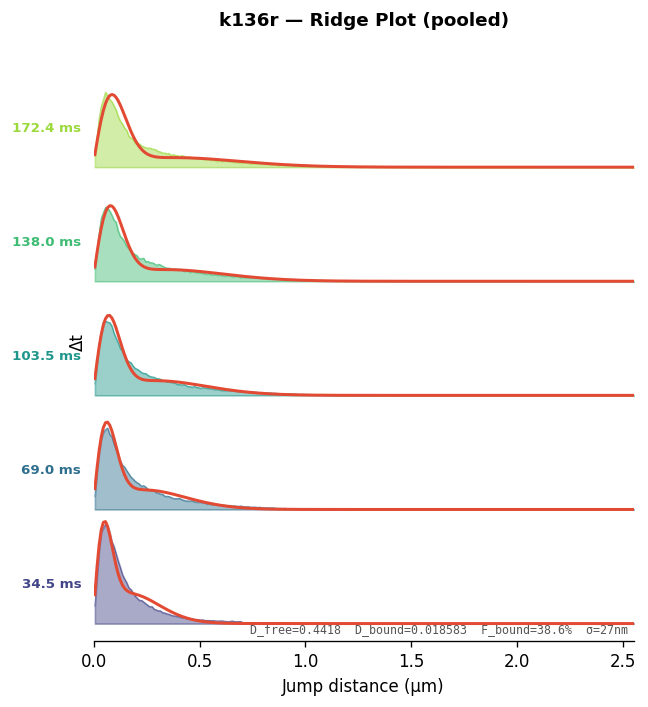

Ridge plot data saved: spoton_ridge_k136r_data.csv  (1500 rows)

── wtTDP ──
  Pooled: 30,279 tracks, 246,913 detections (17 files)


C:\Users\MQ10002204\AppData\Local\anaconda3\envs\SMT\lib\site-packages\fastspt\fastspt.py:552: RuntimeWarning: invalid value encountered in divide
  norm_y[i,:] = y[i,:]/y[i,:].sum()


  D_free=0.4554  D_bound=0.012684  F_bound=49.7%
Figure saved: spoton_ridge_wtTDP.png


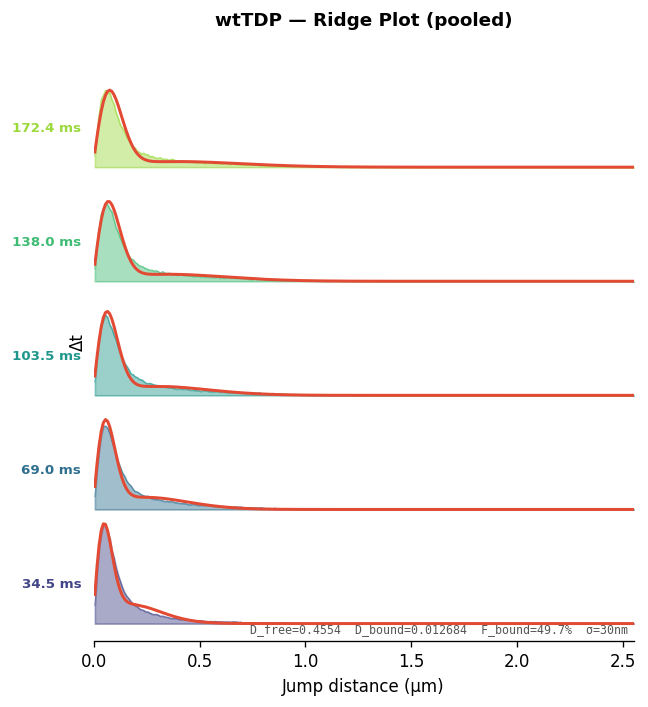

Ridge plot data saved: spoton_ridge_wtTDP_data.csv  (1500 rows)

══════════════════════════════════════════════════════════════════════
  POOLED CONDITION COMPARISON
══════════════════════════════════════════════════════════════════════

  k136r  (24 files, 51,164 tracks pooled)
    D_free  = 0.4418 µm²/s
    D_bound = 0.018583 µm²/s
    F_bound = 38.6%
    σ_loc   = 26.5 nm
    SSQ     = 9.38e-05

  wtTDP  (17 files, 30,279 tracks pooled)
    D_free  = 0.4554 µm²/s
    D_bound = 0.012684 µm²/s
    F_bound = 49.7%
    σ_loc   = 29.7 nm
    SSQ     = 7.91e-05



In [7]:
# ── Run this AFTER the batch cell above has completed ──
# Uses the same folder and settings.

if HAS_WIDGETS:
    _folder = _batch.get('folder') or w_folder.value
    _pattern = w_pattern.value
else:
    _folder = BATCH_FOLDER
    _pattern = FILE_PATTERN

pooled_results = batch_pooled_histograms(
    _folder, file_pattern=_pattern,
    config=CONFIG)


### 4c. Per-Cell QC Browser

Browse individual cells with a dropdown selector.
Each cell is fitted independently — use this to spot outliers,
check fit quality, and identify cells with poor tracking.


In [8]:
# ── Per-cell QC browser ──
# Uses pre-computed histogram data from the batch run above.
# No re-fitting needed.

if HAS_WIDGETS:
    _precomp = _batch.get('cell_data')
else:
    _precomp = _batch_cell_data if '_batch_cell_data' in dir() else None

if _precomp:
    cell_results = batch_cell_browser(precomputed=_precomp, config=CONFIG)
else:
    print('Run batch analysis (4a) first to populate cell data.')


Loaded 41 pre-computed cells for browsing.


---

## Methods Summary

Generate a concise methods paragraph summarising how this dataset was analysed.
Optionally upload a **TrackMate XML** to include tracking parameters.

Outputs a printout and a downloadable `methods_summary.txt`.


In [9]:
# ── Methods summary ──
# Optionally point to a TrackMate XML to include tracking parameters.
# Leave as None to skip.

TRACKMATE_XML = None   # e.g. 'path/to/your/TrackMate_save.xml'

if HAS_WIDGETS:
    import tkinter as tk
    from tkinter import filedialog as fd

    _methods_state = {'xml_path': None}
    methods_output = widgets.Output()

    w_xml = widgets.Text(
        value='', placeholder='(Optional) Paste TrackMate XML path or Browse...',
        description='XML:', style={'description_width': '40px'},
        layout=widgets.Layout(width='500px'))

    browse_xml = widgets.Button(
        description='  Browse XML...', icon='folder-open',
        button_style='info',
        layout=widgets.Layout(width='140px', height='32px'))

    gen_btn = widgets.Button(
        description='  Generate Methods Summary', icon='file-text-o',
        button_style='success',
        layout=widgets.Layout(width='260px', height='36px'))

    def on_browse_xml(btn):
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        path = fd.askopenfilename(
            title='Select TrackMate XML',
            filetypes=[('XML files', '*.xml'), ('All files', '*.*')])
        root.destroy()
        if path:
            w_xml.value = path
            _methods_state['xml_path'] = path

    def on_generate(btn):
        with methods_output:
            from IPython.display import clear_output
            clear_output()
            xml_path = _methods_state.get('xml_path') or w_xml.value or None
            tm_info = None
            if xml_path and xml_path.strip():
                try:
                    tm_info = parse_trackmate_settings(xml_path.strip())
                    print(f'Parsed TrackMate XML: {Path(xml_path).name}')
                    print(f'  Detector: {tm_info.get("detector", "?")}')
                    print(f'  Tracker:  {tm_info.get("tracker", "?")}')
                    print()
                except Exception as e:
                    print(f'Could not parse XML: {e}')
                    print('Continuing without TrackMate info...\n')
            
            generate_methods_summary(CONFIG, trackmate_info=tm_info,
                                    save_path='methods_summary.txt')

    browse_xml.on_click(on_browse_xml)
    gen_btn.on_click(on_generate)

    display(widgets.VBox([
        widgets.HTML('<h3 style="color:#2c3e50">Methods Summary</h3>'),
        widgets.HTML('<p style="color:#666">Optionally upload a TrackMate XML '
                     'to include tracking parameters.</p>'),
        widgets.HBox([w_xml, browse_xml]),
        widgets.HTML('<div style="height:6px"></div>'),
        gen_btn,
        methods_output,
    ], layout=widgets.Layout(padding='10px', border='1px solid #ddd',
                              border_radius='8px', max_width='700px')))

else:
    # No widgets — just generate directly
    tm_info = None
    if TRACKMATE_XML:
        tm_info = parse_trackmate_settings(TRACKMATE_XML)
    generate_methods_summary(CONFIG, trackmate_info=tm_info,
                            save_path='methods_summary.txt')


---

## 5. Path B — Single File Analysis

For detailed exploration of one dataset: QC plots, jump length histograms,
model fitting, interactive parameter explorer, and export.


In [ ]:
# ═══════════════════════════════════════════════════════════
# DATA FILE SELECTION
# ═══════════════════════════════════════════════════════════

if HAS_WIDGETS:
    import tkinter as tk
    from tkinter import filedialog

    _file_state = {'path': ''}  # mutable container

    w_filepath = widgets.Text(
        value='', placeholder='Paste path or click Browse...',
        description='Data file:', 
        style={'description_width': '80px'},
        layout=widgets.Layout(width='550px'))

    browse_btn = widgets.Button(
        description='  Browse...', icon='folder-open',
        button_style='info',
        layout=widgets.Layout(width='130px', height='32px'))

    file_status = widgets.Output()

    def on_browse(btn):
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        path = filedialog.askopenfilename(
            title='Select trajectory data file',
            filetypes=[
                ('All supported', '*.xml *.csv *.tsv'),
                ('TrackMate XML', '*.xml'),
                ('CSV files', '*.csv *.tsv'),
                ('All files', '*.*'),
            ])
        root.destroy()
        if path:
            w_filepath.value = path
            _file_state['path'] = path
            with file_status:
                from IPython.display import clear_output
                clear_output()
                import os
                size_kb = os.path.getsize(path) / 1024
                print(f'Selected: {os.path.basename(path)} ({size_kb:.0f} KB)')

    def on_path_change(change):
        _file_state['path'] = change['new']

    browse_btn.on_click(on_browse)
    w_filepath.observe(on_path_change, names='value')

    display(widgets.VBox([
        widgets.HTML('<b>Select your trajectory data file</b> (.xml or .csv)'),
        widgets.HBox([w_filepath, browse_btn]),
        file_status,
    ]))

    # DATA_FILE will be read from the widget when the next cell runs
else:
    _file_state = {'path': ''}
    # ── Set path manually if no widgets ──
    _file_state['path'] = 'path/to/your/data_file.xml'   # EDIT THIS
    print(f'DATA_FILE = {_file_state["path"]}')


In [ ]:
# ── Load the data ──
DATA_FILE = _file_state.get('path', '') or (w_filepath.value if HAS_WIDGETS else '')
if not DATA_FILE or DATA_FILE.startswith('path/to'):
    raise ValueError('No file selected — use the file picker above or set _file_state["path"]')
print(f'Loading: {DATA_FILE}')
ext = Path(DATA_FILE).suffix.lower()

if ext == '.xml':
    traces = load_trackmate_xml_to_traces(DATA_FILE, FRAME_INTERVAL, PIXEL_SIZE,
                                           DATA_IN_UM, gaps_allowed=GAPS_ALLOWED)
elif ext in ('.csv', '.tsv', '.xlsx', '.xls'):
    traces = load_csv_to_traces(DATA_FILE, FRAME_INTERVAL, PIXEL_SIZE,
                                 DATA_IN_UM, gaps_allowed=GAPS_ALLOWED)
else:
    raise ValueError(f'Unsupported file type: {ext}')

# Convert to fastspt trackedPar format
trackedPar = to_fastSPT(traces, from_json=False)

n_tracks = len(trackedPar)
n_spots = sum(t[0].shape[0] for t in trackedPar)
track_lengths = [t[0].shape[0] for t in trackedPar]

print(f'\nLoaded {n_spots:,} detections across {n_tracks:,} tracks ✓')
print(f'  Track lengths: min={min(track_lengths)}, median={int(np.median(track_lengths))}, max={max(track_lengths)}')
print(f'  Format: fastspt trackedPar ({type(trackedPar).__name__}, {trackedPar.dtype})')


## 5a. Quality Control

In [ ]:
# Gather QC data
all_x = np.concatenate([t[0][:, 0] for t in trackedPar])
all_y = np.concatenate([t[0][:, 1] for t in trackedPar])
all_frames = np.concatenate([t[2][0] for t in trackedPar])
track_lens = np.array([t[0].shape[0] for t in trackedPar])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Track length histogram
max_bin = min(int(track_lens.max()) + 2, 52)
axes[0].hist(track_lens, bins=range(1, max_bin),
             color='#4a90d9', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].set_xlabel('Track length (frames)')
axes[0].set_ylabel('Count')
axes[0].set_title('Track Length Distribution')
axes[0].text(0.95, 0.95, f'n = {len(track_lens):,} tracks',
            transform=axes[0].transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Spatial distribution
axes[1].scatter(all_x, all_y, s=0.3, alpha=0.15, c='#2c3e50', rasterized=True)
axes[1].set_xlabel('x (µm)')
axes[1].set_ylabel('y (µm)')
axes[1].set_title('Spatial Distribution')
axes[1].set_aspect('equal')

# Detections per frame
frame_vals, frame_counts = np.unique(all_frames.astype(int), return_counts=True)
axes[2].plot(frame_vals, frame_counts, lw=0.8, color='#4a90d9')
axes[2].set_xlabel('Frame')
axes[2].set_ylabel('Detections')
axes[2].set_title('Detections per Frame')

plt.tight_layout()
plt.show()

print(f'Tracks with ≥3 detections: {np.sum(track_lens >= 3):,} / {len(track_lens):,}')
print(f'X range: {all_x.min():.3f} – {all_x.max():.3f} µm')
print(f'Y range: {all_y.min():.3f} – {all_y.max():.3f} µm')
print(f'Frame range: {int(all_frames.min())} – {int(all_frames.max())}')

## 5b. Compute Jump Length Distributions

Uses `fastspt.compute_jump_length_distribution()` — the same function
as the Spot-On web GUI.

In [ ]:
CDF_needed = (FIT_TO == 'CDF')

print('Computing jump length distributions...')
print(f'  TimePoints={TIME_POINTS}, JumpsToConsider={JUMPS_TO_CONSIDER}, '
      f'GapsAllowed={GAPS_ALLOWED}')
print(f'  MaxJump={MAX_JUMP} µm, BinWidth={BIN_WIDTH} µm')
print(f'  useEntireTraj={USE_ENTIRE_TRAJ}')
print()

if CDF_needed:
    HistVecJumpsCDF, JumpProbCDF, HistVecJumps, JumpProb, info = \
        compute_jump_length_distribution(
            trackedPar,
            CDF=True,
            useEntireTraj=USE_ENTIRE_TRAJ,
            TimePoints=TIME_POINTS,
            GapsAllowed=GAPS_ALLOWED,
            JumpsToConsider=JUMPS_TO_CONSIDER,
            MaxJump=MAX_JUMP,
            BinWidth=BIN_WIDTH,
        )
else:
    HistVecJumps, JumpProb, info = \
        compute_jump_length_distribution(
            trackedPar,
            CDF=False,
            useEntireTraj=USE_ENTIRE_TRAJ,
            TimePoints=TIME_POINTS,
            GapsAllowed=GAPS_ALLOWED,
            JumpsToConsider=JUMPS_TO_CONSIDER,
            MaxJump=MAX_JUMP,
            BinWidth=BIN_WIDTH,
        )
    # Create dummy CDF arrays (needed by fit function signature)
    HistVecJumpsCDF = np.arange(0, MAX_JUMP + 0.001, 0.001)
    JumpProbCDF = np.zeros((JumpProb.shape[0], len(HistVecJumpsCDF)))

n_lags = JumpProb.shape[0]
print(f'\nComputed {n_lags} time lags ✓  (took {info["time"]:.2f}s)')
for i in range(n_lags):
    dt_ms = (i + 1) * FRAME_INTERVAL * 1000
    total_prob = JumpProb[i].sum()
    print(f'  Δt = {dt_ms:.1f} ms :  total probability mass = {total_prob:.4f}')

In [ ]:
# ── Raw jump length distributions (interactive ridge plot) ──
interactive_ridge(
    JumpProb, None, HistVecJumps,
    n_lags=n_lags, frame_interval=FRAME_INTERVAL,
    max_jump=MAX_JUMP, bin_width=BIN_WIDTH,
    title='Raw Jump Length Distributions',
    save_prefix='spoton_raw_ridge')


## 5c. Fit the Model

Uses `fastspt.fit_jump_length_distribution()` — the same least-squares
fitting procedure (via `lmfit`) as the Spot-On web GUI.

In [ ]:
print(f'Fitting {NUM_STATES}-state model ({FIT_TO})...')
print(f'  Iterations: {ITERATIONS}')
print(f'  Bounds LB: {LB}')
print(f'  Bounds UB: {UB}')
print()

ModelFit = 1 if FIT_TO == 'PDF' else 2
fit2states = (NUM_STATES == 2)

fit_result = fit_jump_length_distribution(
    JumpProb, JumpProbCDF,
    HistVecJumps, HistVecJumpsCDF,
    LB, UB,
    LOC_ERROR,
    ITERATIONS,
    dT=FRAME_INTERVAL,
    dZ=DZ,
    ModelFit=ModelFit,
    a=A_CORR,
    b=B_CORR,
    fit2states=fit2states,
    fitSigma=FIT_SIGMA,
    verbose=True,
    useZcorr=USE_Z_CORR,
)

# ── Extract fitted parameters ──
best = fit_result.params

print()
print('=' * 55)
print('  FIT RESULTS')
print('=' * 55)

if fit2states:
    D_free_fit  = best['D_free'].value
    D_bound_fit = best['D_bound'].value
    F_bound_fit = best['F_bound'].value
    sigma_fit   = best['sigma'].value
    
    print(f'  D_free    = {D_free_fit:.4f} µm²/s')
    print(f'  D_bound   = {D_bound_fit:.6f} µm²/s')
    print(f'  F_bound   = {F_bound_fit:.4f}  ({F_bound_fit*100:.1f}%)')
    print(f'  F_free    = {1-F_bound_fit:.4f}  ({(1-F_bound_fit)*100:.1f}%)')
    print(f'  σ_loc     = {sigma_fit:.4f} µm  ({sigma_fit*1000:.1f} nm)')
else:
    D_fast_fit  = best['D_fast'].value
    D_med_fit   = best['D_med'].value
    D_bound_fit = best['D_bound'].value
    F_fast_fit  = best['F_fast'].value
    F_bound_fit = best['F_bound'].value
    sigma_fit   = best['sigma'].value
    F_med_fit   = 1 - F_fast_fit - F_bound_fit
    
    print(f'  D_fast    = {D_fast_fit:.4f} µm²/s')
    print(f'  D_med     = {D_med_fit:.4f} µm²/s')
    print(f'  D_bound   = {D_bound_fit:.6f} µm²/s')
    print(f'  F_fast    = {F_fast_fit:.4f}  ({F_fast_fit*100:.1f}%)')
    print(f'  F_med     = {F_med_fit:.4f}  ({F_med_fit*100:.1f}%)')
    print(f'  F_bound   = {F_bound_fit:.4f}  ({F_bound_fit*100:.1f}%)')
    print(f'  σ_loc     = {sigma_fit:.4f} µm  ({sigma_fit*1000:.1f} nm)')

print(f'  SSQ       = {best.ssq2:.6e}')
print('=' * 55)

## 5d. Fit Visualization

Overlay the fitted model on the empirical histograms — equivalent to the
Spot-On 'Fitting' tab display.

In [ ]:
# Generate model curves using fastspt
r_fine = np.arange(0, MAX_JUMP + 0.001, 0.001)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', 'invalid value')
    model_curves = generate_jump_length_distribution(
        best,
        JumpProb,
        r_fine,
        sigma_fit,
        dT=FRAME_INTERVAL,
        dZ=DZ,
        a=A_CORR,
        b=B_CORR,
        fit2states=fit2states,
        norm=True,
        useZcorr=USE_Z_CORR,
    )

# Bin model curves to match histogram bins (using corrected binning)
model_binned = bin_model_curves(model_curves, r_fine, HistVecJumps, n_lags)

print('Model curves generated ✓')


In [ ]:
# ── Ridge plot with model fit (interactive) ──
interactive_ridge(
    JumpProb, model_binned, HistVecJumps,
    n_lags=n_lags, frame_interval=FRAME_INTERVAL,
    max_jump=MAX_JUMP, bin_width=BIN_WIDTH,
    fit2states=fit2states, best=best,
    title=f'{Path(DATA_FILE).stem} — Spot-On Fit',
    save_prefix='spoton_fit_ridge')

# ── Residuals ──
plot_spoton_residuals(
    JumpProb, model_binned, HistVecJumps,
    n_lags=n_lags, frame_interval=FRAME_INTERVAL,
    max_jump=MAX_JUMP, bin_width=BIN_WIDTH,
    save_path='spoton_fit_residuals.png')

# ── Component decomposition (bound vs free) ──
plot_component_decomposition(
    best, JumpProb, HistVecJumps,
    n_lags=n_lags, frame_interval=FRAME_INTERVAL,
    max_jump=MAX_JUMP, bin_width=BIN_WIDTH,
    sigma=sigma_fit, dT=FRAME_INTERVAL,
    dZ=DZ, a_corr=A_CORR, b_corr=B_CORR,
    fit2states=fit2states, use_zcorr=USE_Z_CORR,
    save_path='spoton_fit_components.png')


## 5e. Interactive Parameter Explorer

Drag the sliders to see how parameters affect the model — like the
Spot-On GUI fitting controls. *Requires `ipywidgets`.*

In [ ]:
if HAS_WIDGETS and fit2states:
    out = widgets.Output()
    style = {'description_width': '120px'}
    layout = widgets.Layout(width='450px')
    
    w_Dfree = widgets.FloatLogSlider(
        value=best['D_free'].value, base=10, min=-1, max=1.5, step=0.02,
        description='D_free (µm²/s)', style=style, layout=layout)
    w_Dbound = widgets.FloatLogSlider(
        value=best['D_bound'].value, base=10, min=-4, max=-1, step=0.02,
        description='D_bound (µm²/s)', style=style, layout=layout)
    w_Fbound = widgets.FloatSlider(
        value=best['F_bound'].value, min=0, max=1, step=0.005,
        description='F_bound', style=style, layout=layout)
    w_sigma = widgets.FloatSlider(
        value=best['sigma'].value, min=0.005, max=0.15, step=0.001,
        description='σ_loc (µm)', style=style, layout=layout, readout_format='.3f')
    w_dz = widgets.FloatSlider(
        value=DZ, min=0.1, max=2.0, step=0.05,
        description='Δz (µm)', style=style, layout=layout)
    w_zcorr = widgets.Checkbox(value=USE_Z_CORR, description='Z-correction')
    
    bc = HistVecJumps[:-1] + BIN_WIDTH / 2
    
    def update(D_free, D_bound, F_bound, sigma, dz, use_zcorr):
        with out:
            clear_output(wait=True)
            # Use _NumericParam instead of SimpleNamespace (supports arithmetic)
            mock = make_mock_params(
                D_free=D_free, D_bound=D_bound,
                F_bound=F_bound, sigma=sigma)
            try:
                mc = generate_jump_length_distribution(
                    mock, JumpProb, r_fine, sigma,
                    dT=FRAME_INTERVAL, dZ=dz, a=A_CORR, b=B_CORR,
                    fit2states=True, norm=True, useZcorr=use_zcorr)
                mb = bin_model_curves(mc, r_fine, HistVecJumps, n_lags)
                
                n_show = min(n_lags, 4)
                fig, axes = plt.subplots(1, n_show, figsize=(3.5*n_show, 3.5),
                                         sharey=True, squeeze=False)
                axes = axes[0]
                for i in range(n_show):
                    dt_ms = (i+1) * FRAME_INTERVAL * 1000
                    axes[i].bar(bc, JumpProb[i, :-1], width=BIN_WIDTH*0.9,
                               alpha=0.4, color='#4a90d9', edgecolor='white', linewidth=0.3)
                    axes[i].plot(bc, mb[i, :-1], 'r-', lw=2)
                    axes[i].set_xlabel('Jump length (µm)')
                    axes[i].set_title(f'Δt = {dt_ms:.1f} ms')
                    axes[i].set_xlim(0, MAX_JUMP * 0.85)
                axes[0].set_ylabel('Probability')
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f'Error: {e}')
            print(f'D_free={D_free:.4f}  D_bound={D_bound:.6f}  '
                  f'F_bound={F_bound:.1%}  σ={sigma*1000:.1f}nm  Δz={dz}')
    
    interactive = widgets.interactive(update,
        D_free=w_Dfree, D_bound=w_Dbound, F_bound=w_Fbound,
        sigma=w_sigma, dz=w_dz, use_zcorr=w_zcorr)
    
    display(widgets.VBox([
        widgets.HTML('<h3>Parameter Explorer</h3>'),
        widgets.HTML('<p style="color:#666">Drag sliders to see how parameters '
                     'affect the model. Red = model, blue = data.</p>'),
        interactive
    ]))

elif HAS_WIDGETS and not fit2states:
    print('Interactive explorer for 3-state model — coming soon.')
else:
    print('Skipped — install ipywidgets for interactive controls.')

## 5f. Export Results

In [ ]:
# ── Results summary CSV ──
row = {
    'source_file': str(DATA_FILE),
    'model': f'{NUM_STATES}-state',
    'fit_to': FIT_TO,
    'frame_interval_s': FRAME_INTERVAL,
    'loc_error_um': sigma_fit,
    'z_correction': USE_Z_CORR,
    'dz_um': DZ if USE_Z_CORR else None,
    'ssq': best.ssq2,
}

if fit2states:
    row.update({
        'D_free_um2s': best['D_free'].value,
        'D_bound_um2s': best['D_bound'].value,
        'F_bound': best['F_bound'].value,
        'F_free': 1 - best['F_bound'].value,
    })
else:
    row.update({
        'D_fast_um2s': best['D_fast'].value,
        'D_med_um2s': best['D_med'].value,
        'D_bound_um2s': best['D_bound'].value,
        'F_fast': best['F_fast'].value,
        'F_med': 1 - best['F_fast'].value - best['F_bound'].value,
        'F_bound': best['F_bound'].value,
    })

results_df = pd.DataFrame([row])
out_name = Path(DATA_FILE).stem + '_spoton_results.csv'
results_df.to_csv(out_name, index=False)
print(f'Results saved: {out_name}')
display(results_df.T)

# ── Histogram + model curves CSV ──
hist_rows = []
bc = HistVecJumps[:-1] + BIN_WIDTH / 2
for i in range(n_lags):
    dt_ms = (i+1) * FRAME_INTERVAL * 1000
    for j in range(len(bc)):
        hist_rows.append({
            'dt_ms': dt_ms,
            'jump_length_um': bc[j],
            'prob_data': JumpProb[i, j],
            'prob_model': model_binned[i, j],
            'residual': JumpProb[i, j] - model_binned[i, j],
        })

hist_df = pd.DataFrame(hist_rows)
hist_name = Path(DATA_FILE).stem + '_jump_histograms.csv'
hist_df.to_csv(hist_name, index=False)
print(f'Histograms saved: {hist_name}')

---

## Notes & Troubleshooting

**This notebook uses `fastspt` for:**
- Jump length histogram computation (`compute_jump_length_distribution`)
- Model fitting via `lmfit` (`fit_jump_length_distribution`)
- Model curve generation (`generate_jump_length_distribution`)
- Defocalization Z-correction (`C_AbsorBoundAUTO`)

**Our additions on top:**
- Auto-patching for Python 3 / NumPy 2 compatibility
- TrackMate full XML parser (fastspt's built-in reader expects the simple tracks export)
- **Gap-splitting** — splits tracks at large frame gaps to prevent fastspt IndexError
- **XLSX/XLS support** — reads Excel files in addition to CSV/TSV
- Spot-On web GUI style histograms (`plot_spoton_histograms`)
- Component decomposition plot (`plot_component_decomposition`)
- Interactive parameter explorer with ipywidgets (using arithmetic-safe mock params)
- Publication-quality 4-panel figure
- Batch comparison for multiple conditions (supports `*.csv,*.xlsx` patterns)
- CSV export of results and histograms

**Troubleshooting:**

| Issue | Fix |
|---|---|
| `SyntaxError: from . from .` | Re-run Cell 1. If persistent: `pip uninstall fastspt -y && pip install fastspt`, then re-run Cell 1 |
| `np.float_ not found` | Re-run Cell 1 — it patches this automatically |
| `IndexError` in batch mode | Fixed — tracks are now split at large frame gaps before fastspt processing |
| `ModuleNotFoundError: lmfit` | `pip install lmfit` |
| `ModuleNotFoundError: openpyxl` | `pip install openpyxl` (needed for XLSX reading) |
| `ModuleNotFoundError: xmltodict` | `pip install xmltodict` (only needed for fastspt's built-in XML reader) |
| Fit doesn't converge | Try wider bounds (LB/UB), more ITERATIONS, or check frame interval |
| F_bound near 0% or 100% | Bounds may be too tight, or data quality issue — check QC plots |

**Key parameters to get right:**
- `FRAME_INTERVAL` — must match your acquisition exactly (check .nd2 metadata)
- `DZ` — axial detection range; 0.7 µm is the Spot-On default for typical objectives
- `LOC_ERROR` — localization precision; measure from fixed-cell data or bright beads
- `TIME_POINTS` — number of frame-gaps for fitting; 8 is default, reduce if later lags are noisy

**Citation:**
Hansen AS, Woringer M, Grimm JB, Lavis LD, Tjian R, Darzacq X (2018).
Robust model-based analysis of single-particle tracking experiments with Spot-On.
*eLife* 7:e33125. https://doi.org/10.7554/eLife.33125